# Degree Distribution Evolution Analysis (2004-2024)

This notebook analyzes the evolution of node degree distributions across communities over time.
We focus on communities 0, 1, and 2 and visualize degree distribution changes from 2004 to 2024.

## Setup and Imports

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import gaussian_kde
import warnings
import os
from mpl_toolkits.mplot3d import Axes3D
from matplotlib import cm
from matplotlib.colors import Normalize
import networkx as nx
from collections import Counter

warnings.filterwarnings('ignore')

# Set style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')

# Configuration
min_year = 2004
max_year = 2024
target_communities = [0, 1, 2]

## Data Loading and Preparation

In [ ]:
# Set paths
processed_dir = '../../data/processed/us'
figures_dir = '../../reports/figures/us/degree_evolution'

# Create output directory if it doesn't exist
os.makedirs(figures_dir, exist_ok=True)

# Load nodes and edges data
nodes_df = pd.read_csv(os.path.join(processed_dir, 'nodes.csv'))
edges_df = pd.read_csv(os.path.join(processed_dir, 'edges.csv'))

print(f"Nodes shape: {nodes_df.shape}")
print(f"Edges shape: {edges_df.shape}")
print(f"\nNodes columns: {nodes_df.columns.tolist()}")
print(f"\nEdges columns: {edges_df.columns.tolist()}")
print(f"\nFirst few nodes:")
print(nodes_df.head())
print(f"\nFirst few edges:")
print(edges_df.head())

Nodes shape: (15347, 7)
Edges shape: (156481, 24)

Nodes columns: ['index', 'index.1', 'community_id', 'node', 'community_size', 'id', 'set']

Edges columns: ['index', 'investor_name_left', 'investor_name_right', 'announced_year_left', 'announced_year_right', 'org_uuid', 'total_funding_usd', 'total_funding_usd_left', 'total_funding_usd_right', 'year', 'company_country', 'investor_country_left', 'investor_country_right', 'investor_region_left', 'investor_region_right', 'investment_type_left', 'investment_type_right', 'category_left', 'category_right', 'community_left', 'community_right', 'community', 'Source', 'Target']

First few nodes:
   index  index.1  community_id                          node  community_size  \
0      0        0             0  Ironspring Ventures-series_a            4212   
1      1        1             0                 Bolt-series_a            4212   
2      2        2             0          NightDragon-series_e            4212   
3      3        3             0

In [6]:
# Build bipartite graph for each year and community
# This will track degree evolution

def build_yearly_graphs(edges_df, nodes_df, target_communities):
    """Build yearly graphs for each community"""
    yearly_graphs = {}
    yearly_degrees = {}
    
    # Filter edges for target communities
    edges_with_comm = edges_df.copy()
    edges_with_comm['year'] = edges_with_comm['year'].fillna(edges_with_comm['announced_year_left']).fillna(edges_with_comm['announced_year_right']).astype(int)
    
    # Create node to community mapping
    node_to_community = dict(zip(nodes_df['id'], nodes_df['community_id']))
    
    for comm_id in target_communities:
        comm_nodes = set(nodes_df[nodes_df['community_id'] == comm_id]['id'].values)
        yearly_graphs[comm_id] = {}
        yearly_degrees[comm_id] = {}
        
        for year in range(min_year, max_year + 1):
            # Get cumulative edges up to this year for this community
            year_edges = edges_with_comm[
                (edges_with_comm['year'] <= year) &
                (edges_with_comm['year'] >= year - 20)  # 20-year window
            ].copy()
            
            # Filter edges where both investors are in this community
            relevant_edges = []
            for _, edge in year_edges.iterrows():
                left = edge.get('investor_name_left')
                right = edge.get('investor_name_right')
                if left and right and left in comm_nodes and right in comm_nodes:
                    relevant_edges.append((left, right))
            
            if len(relevant_edges) > 0:
                # Create networkx graph
                G = nx.Graph()
                G.add_edges_from(relevant_edges)
                
                # Only include nodes that are in community and have edges
                degree_dict = dict(G.degree())
                
                yearly_graphs[comm_id][year] = G
                yearly_degrees[comm_id][year] = degree_dict
    
    return yearly_graphs, yearly_degrees

print("Building yearly graphs...")
yearly_graphs, yearly_degrees = build_yearly_graphs(edges_df, nodes_df, target_communities)

# Summary statistics
for comm_id in target_communities:
    years_with_data = sorted([y for y in yearly_degrees[comm_id].keys() if len(yearly_degrees[comm_id][y]) > 0])
    print(f"\nCommunity {comm_id}: {len(years_with_data)} years with data")
    if years_with_data:
        print(f"  Year range: {years_with_data[0]} to {years_with_data[-1]}")
        print(f"  Sample year {years_with_data[-1]}: {len(yearly_degrees[comm_id][years_with_data[-1]])} nodes")

Building yearly graphs...

Community 0: 21 years with data
  Year range: 2004 to 2024
  Sample year 2024: 4182 nodes

Community 1: 21 years with data
  Year range: 2004 to 2024
  Sample year 2024: 3952 nodes

Community 2: 21 years with data
  Year range: 2004 to 2024
  Sample year 2024: 4024 nodes

Community 0: 21 years with data
  Year range: 2004 to 2024
  Sample year 2024: 4182 nodes

Community 1: 21 years with data
  Year range: 2004 to 2024
  Sample year 2024: 3952 nodes

Community 2: 21 years with data
  Year range: 2004 to 2024
  Sample year 2024: 4024 nodes


## Visualization 1: Heatmap - Degree Distribution Evolution

Shows how degree frequencies change over time for each community.
Darker colors indicate higher frequency of nodes with specific degrees.

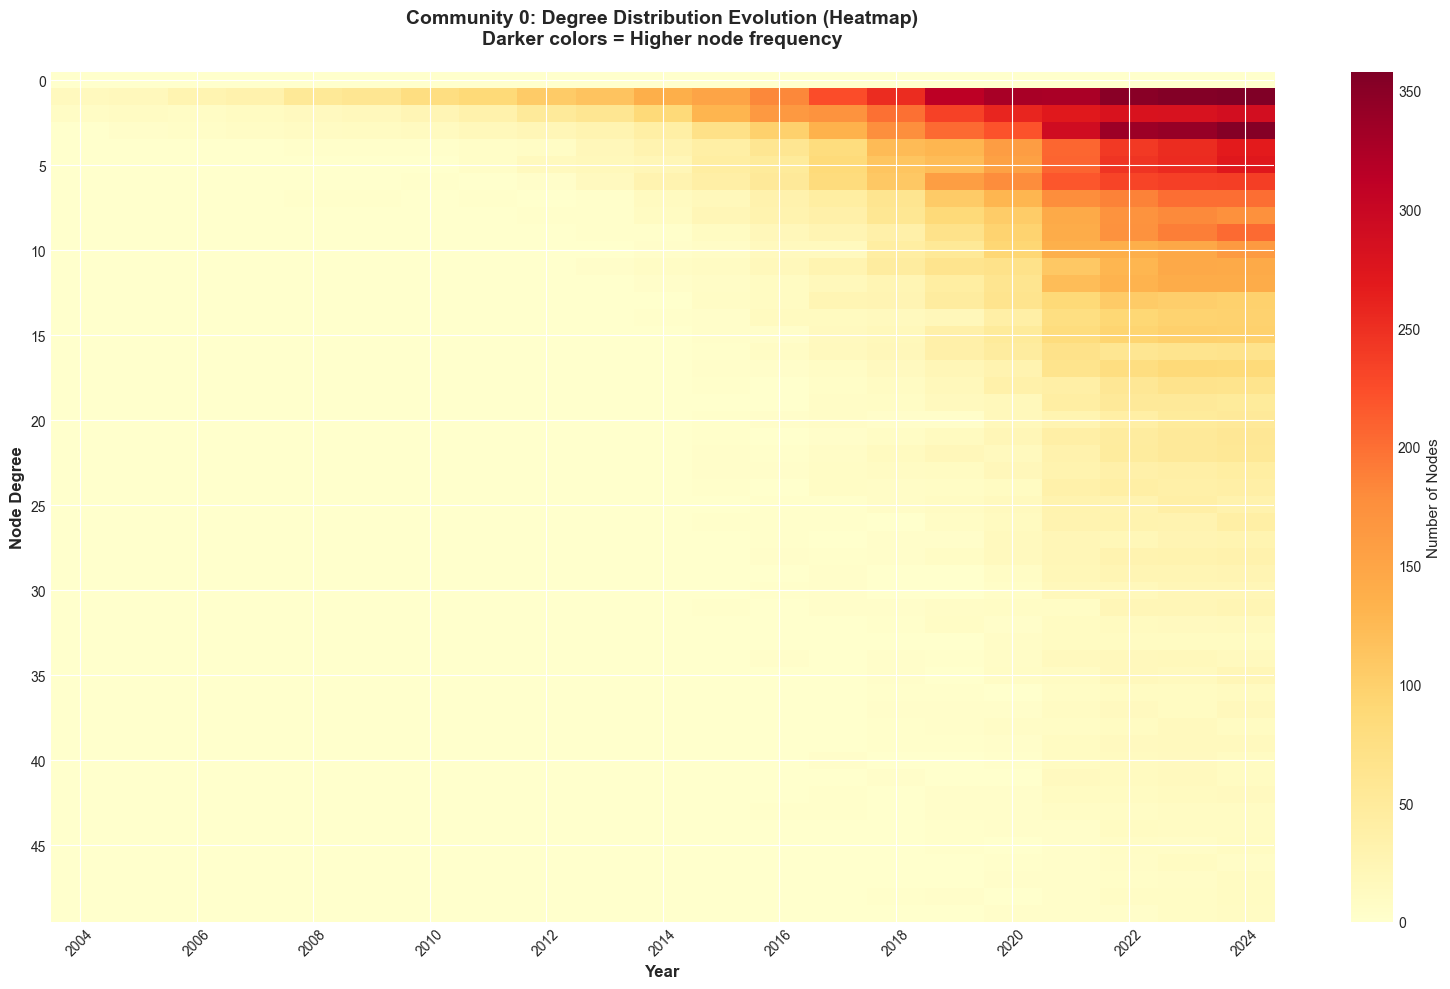

Community 0: Heatmap generated


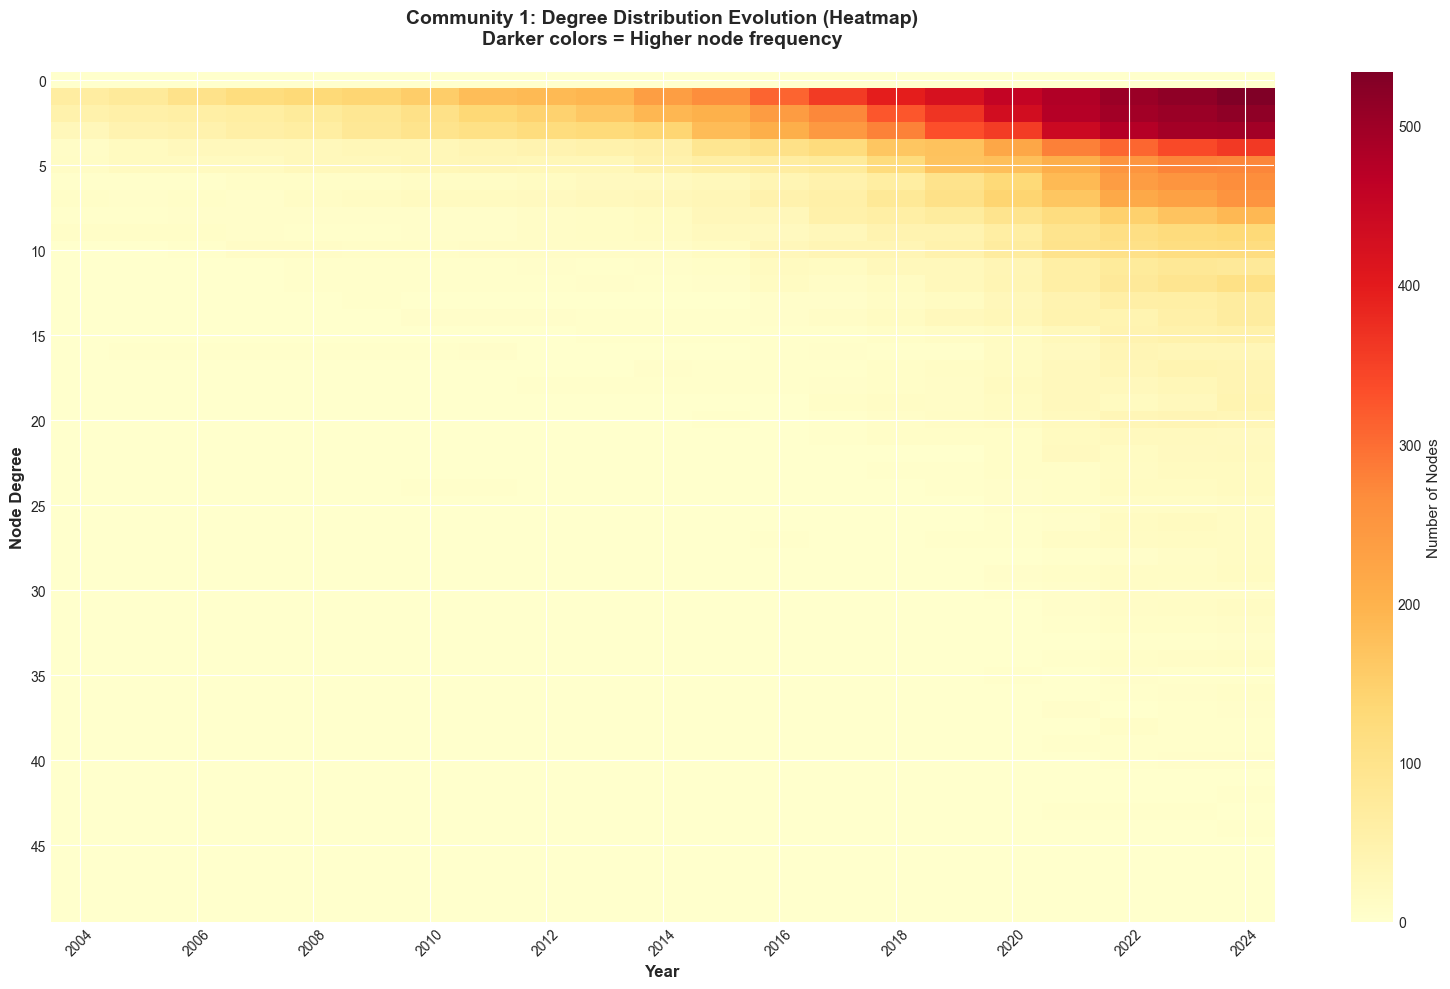

Community 1: Heatmap generated


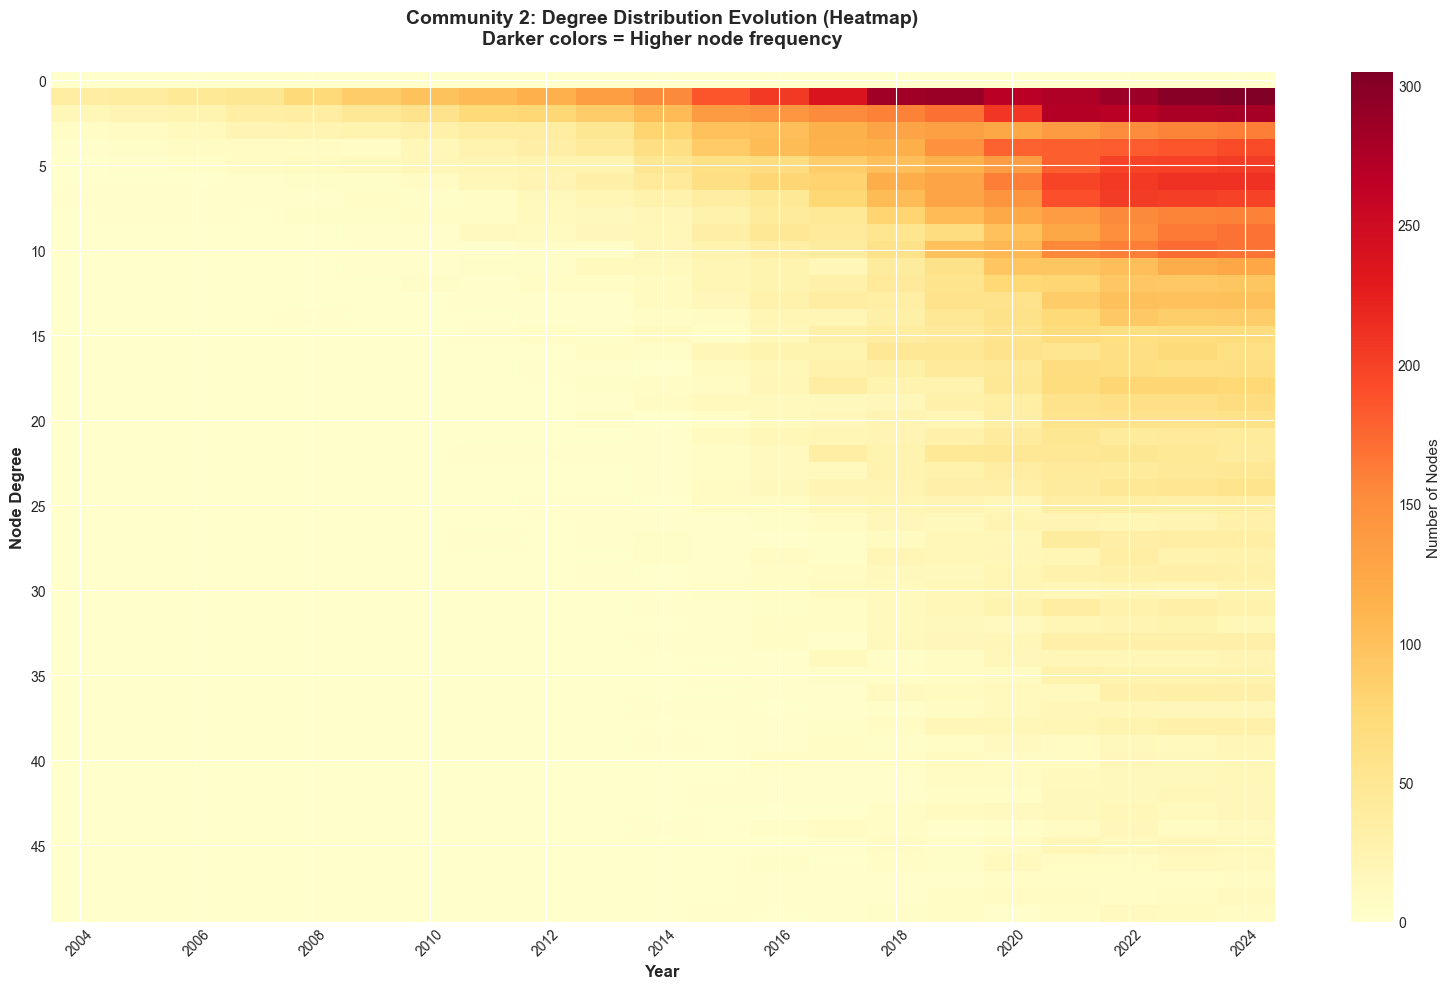

Community 2: Heatmap generated


In [7]:
def create_degree_heatmap(yearly_degrees, comm_id, target_communities, figures_dir, min_year, max_year):
    """Create heatmap of degree distribution evolution"""
    
    # Get years with data
    years_with_data = sorted([y for y in yearly_degrees[comm_id].keys() if len(yearly_degrees[comm_id][y]) > 0])
    
    if len(years_with_data) < 2:
        print(f"Community {comm_id}: Not enough data for heatmap")
        return
    
    # Get max degree for binning
    all_degrees = []
    for year in years_with_data:
        all_degrees.extend(yearly_degrees[comm_id][year].values())
    
    max_degree = max(all_degrees) if all_degrees else 0
    
    # Create degree bins
    degree_bins = np.arange(0, min(int(max_degree) + 2, 50))  # Cap at 50 for visualization
    
    # Create matrix: rows=degrees, cols=years
    heatmap_data = []
    for degree_bin in degree_bins:
        row = []
        for year in years_with_data:
            degrees_in_year = yearly_degrees[comm_id][year].values()
            count = sum(1 for d in degrees_in_year if d == degree_bin)
            row.append(count)
        heatmap_data.append(row)
    
    heatmap_data = np.array(heatmap_data)
    
    # Create figure
    fig, ax = plt.subplots(figsize=(16, 10))
    
    # Plot heatmap
    im = ax.imshow(heatmap_data, aspect='auto', cmap='YlOrRd', interpolation='nearest')
    
    # Set ticks
    ax.set_xticks(np.arange(0, len(years_with_data), max(1, len(years_with_data)//10)))
    ax.set_xticklabels([years_with_data[i] for i in range(0, len(years_with_data), max(1, len(years_with_data)//10))], rotation=45)
    
    ax.set_yticks(np.arange(0, len(degree_bins), max(1, len(degree_bins)//10)))
    ax.set_yticklabels([degree_bins[i] for i in range(0, len(degree_bins), max(1, len(degree_bins)//10))])
    
    ax.set_xlabel('Year', fontsize=12, fontweight='bold')
    ax.set_ylabel('Node Degree', fontsize=12, fontweight='bold')
    ax.set_title(f'Community {comm_id}: Degree Distribution Evolution (Heatmap)\nDarker colors = Higher node frequency', 
                fontsize=14, fontweight='bold', pad=20)
    
    # Add colorbar
    cbar = plt.colorbar(im, ax=ax)
    cbar.set_label('Number of Nodes', fontsize=11)
    
    plt.tight_layout()
    plt.savefig(os.path.join(figures_dir, f'01_heatmap_degree_distribution_community_{comm_id}.png'), dpi=300, bbox_inches='tight')
    plt.show()
    
    print(f"Community {comm_id}: Heatmap generated")

# Generate heatmaps for all communities
for comm_id in target_communities:
    create_degree_heatmap(yearly_degrees, comm_id, target_communities, figures_dir, min_year, max_year)

## Visualization 2: Ridge Plot - KDE Density Evolution

Shows the shape of degree distributions over time as stacked density curves.
Useful for seeing how distributions shift and change shape over years.

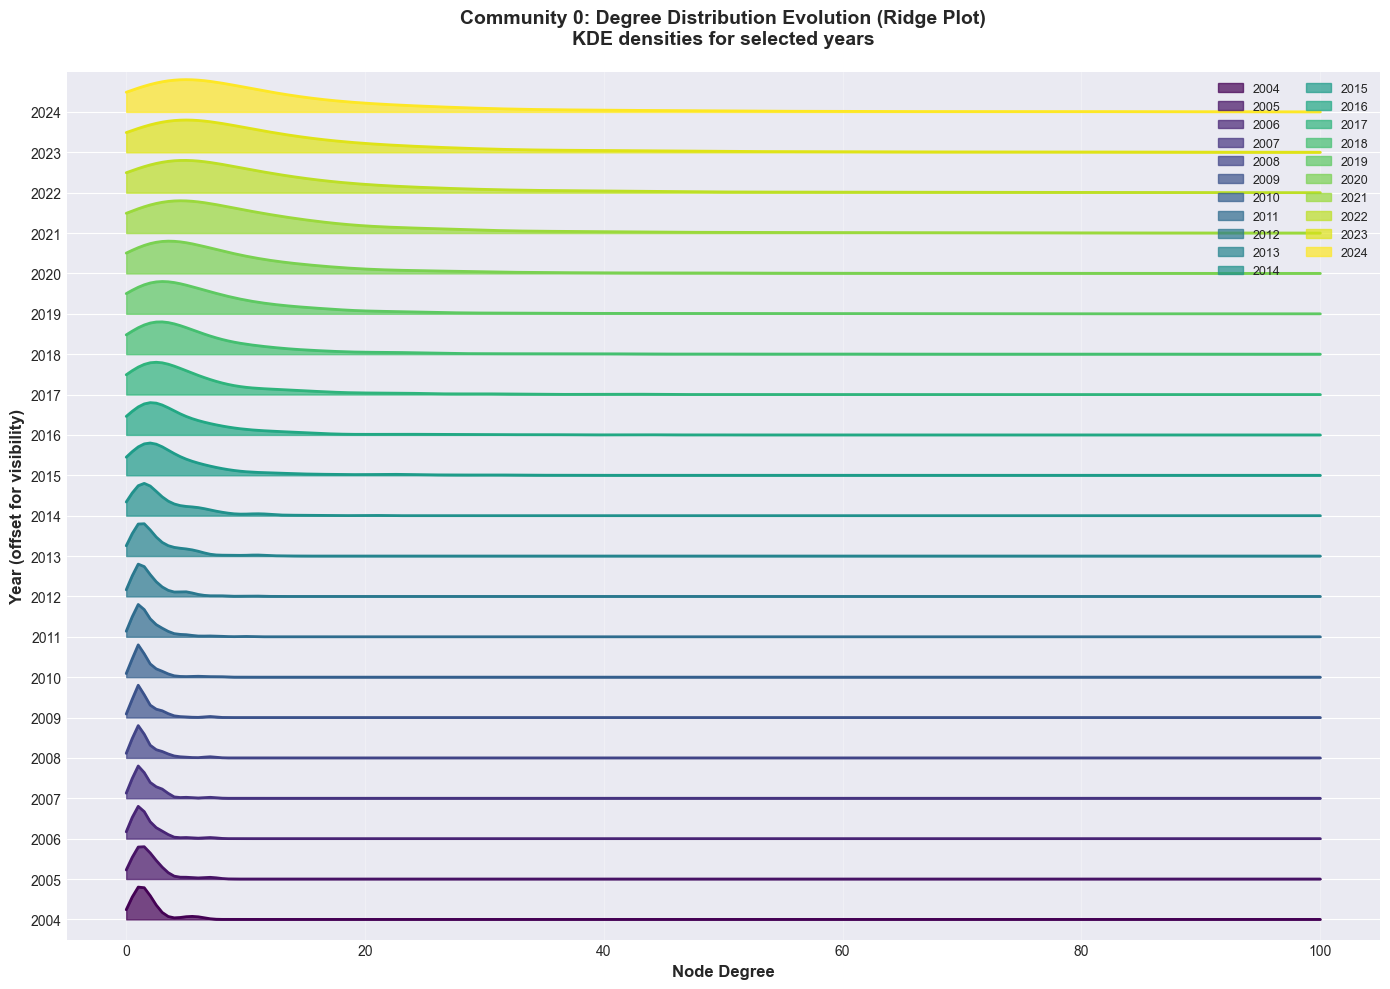

Community 0: Ridge plot generated (21 years)


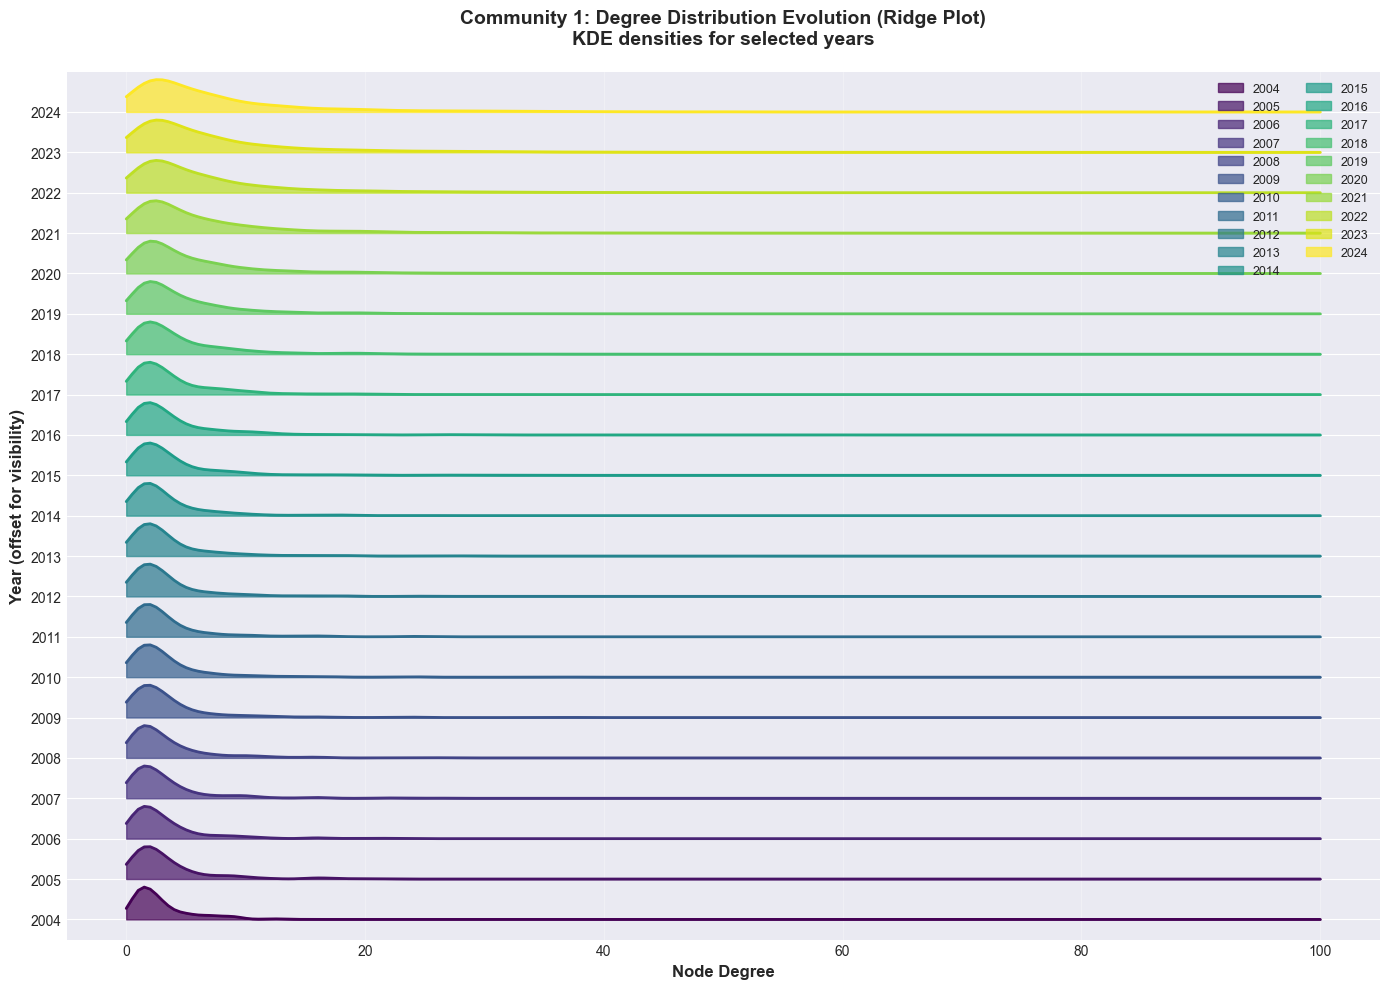

Community 1: Ridge plot generated (21 years)


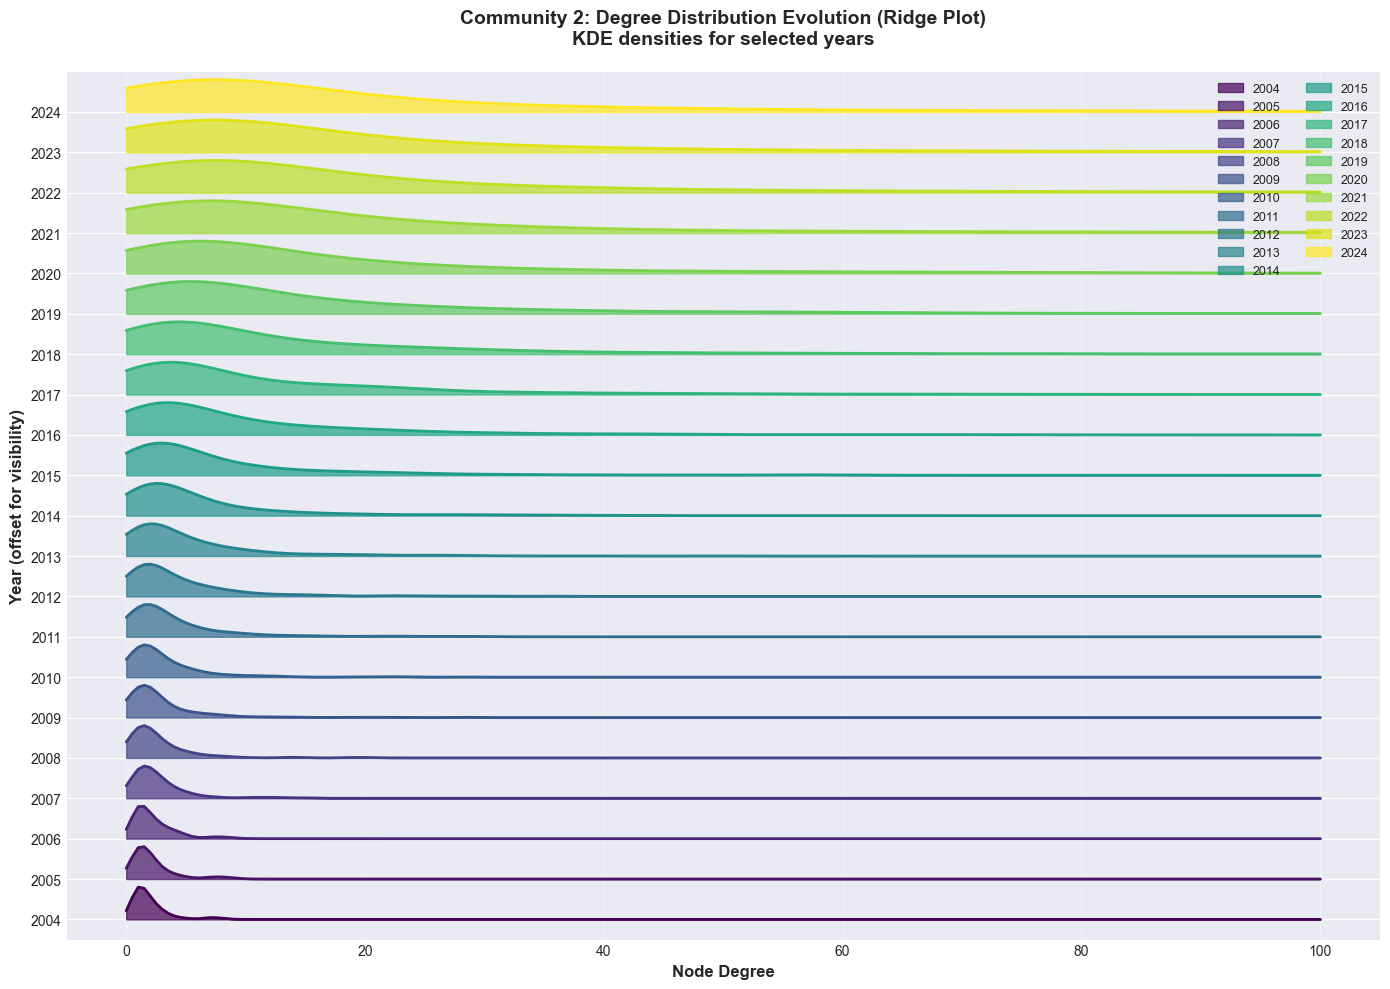

Community 2: Ridge plot generated (21 years)


In [8]:
def create_ridge_plot(yearly_degrees, comm_id, figures_dir):
    """Create ridge plot of degree distribution evolution"""
    
    # Get years with data, select every 2-3 years for clarity
    years_with_data = sorted([y for y in yearly_degrees[comm_id].keys() if len(yearly_degrees[comm_id][y]) > 5])
    
    if len(years_with_data) < 3:
        print(f"Community {comm_id}: Not enough data for ridge plot")
        return
    
    # Subsample years for clarity (every 3rd year)
    selected_years = years_with_data[::max(1, len(years_with_data)//12)]  # Show ~12 years
    if years_with_data[-1] not in selected_years:
        selected_years.append(years_with_data[-1])
    
    fig, ax = plt.subplots(figsize=(14, 10))
    
    # Color palette
    colors = plt.cm.viridis(np.linspace(0, 1, len(selected_years)))
    
    max_degree = 0
    for year in selected_years:
        degrees = list(yearly_degrees[comm_id][year].values())
        max_degree = max(max_degree, max(degrees) if degrees else 0)
    
    # Create KDE curves for each year
    for idx, year in enumerate(selected_years):
        degrees = np.array(list(yearly_degrees[comm_id][year].values()))
        
        if len(degrees) > 1:
            # Create KDE
            kde = gaussian_kde(degrees)
            x_range = np.linspace(0, min(max_degree, 100), 200)
            density = kde(x_range)
            
            # Normalize and offset for ridge effect
            density = density / density.max() * 0.8
            
            # Plot
            ax.fill_between(x_range, idx, density + idx, alpha=0.7, color=colors[idx], label=str(year))
            ax.plot(x_range, density + idx, color=colors[idx], linewidth=2)
    
    ax.set_xlabel('Node Degree', fontsize=12, fontweight='bold')
    ax.set_ylabel('Year (offset for visibility)', fontsize=12, fontweight='bold')
    ax.set_title(f'Community {comm_id}: Degree Distribution Evolution (Ridge Plot)\nKDE densities for selected years', 
                fontsize=14, fontweight='bold', pad=20)
    ax.set_ylim(-0.5, len(selected_years))
    ax.set_yticks(range(len(selected_years)))
    ax.set_yticklabels(selected_years)
    ax.grid(True, alpha=0.3, axis='x')
    ax.legend(loc='upper right', ncol=2, fontsize=9)
    
    plt.tight_layout()
    plt.savefig(os.path.join(figures_dir, f'02_ridge_plot_community_{comm_id}.png'), dpi=300, bbox_inches='tight')
    plt.show()
    
    print(f"Community {comm_id}: Ridge plot generated ({len(selected_years)} years)")

# Generate ridge plots for all communities
for comm_id in target_communities:
    create_ridge_plot(yearly_degrees, comm_id, figures_dir)

## Visualization 3: 3D Surface Plot - Degree Distribution Over Time

3D visualization showing degree (X), year (Z), and frequency (Y).
Useful for seeing the full evolution landscape.

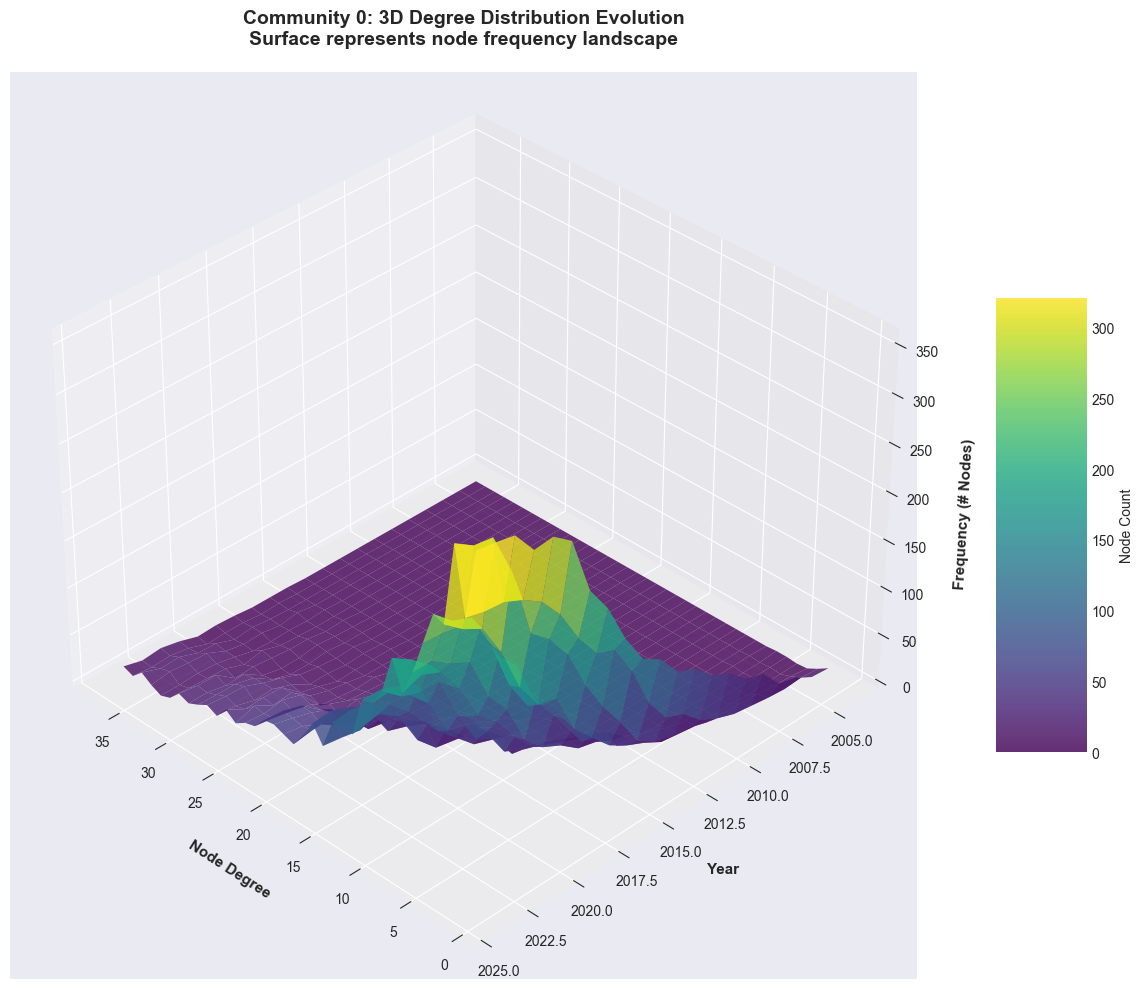

Community 0: 3D surface plots generated (2 views)


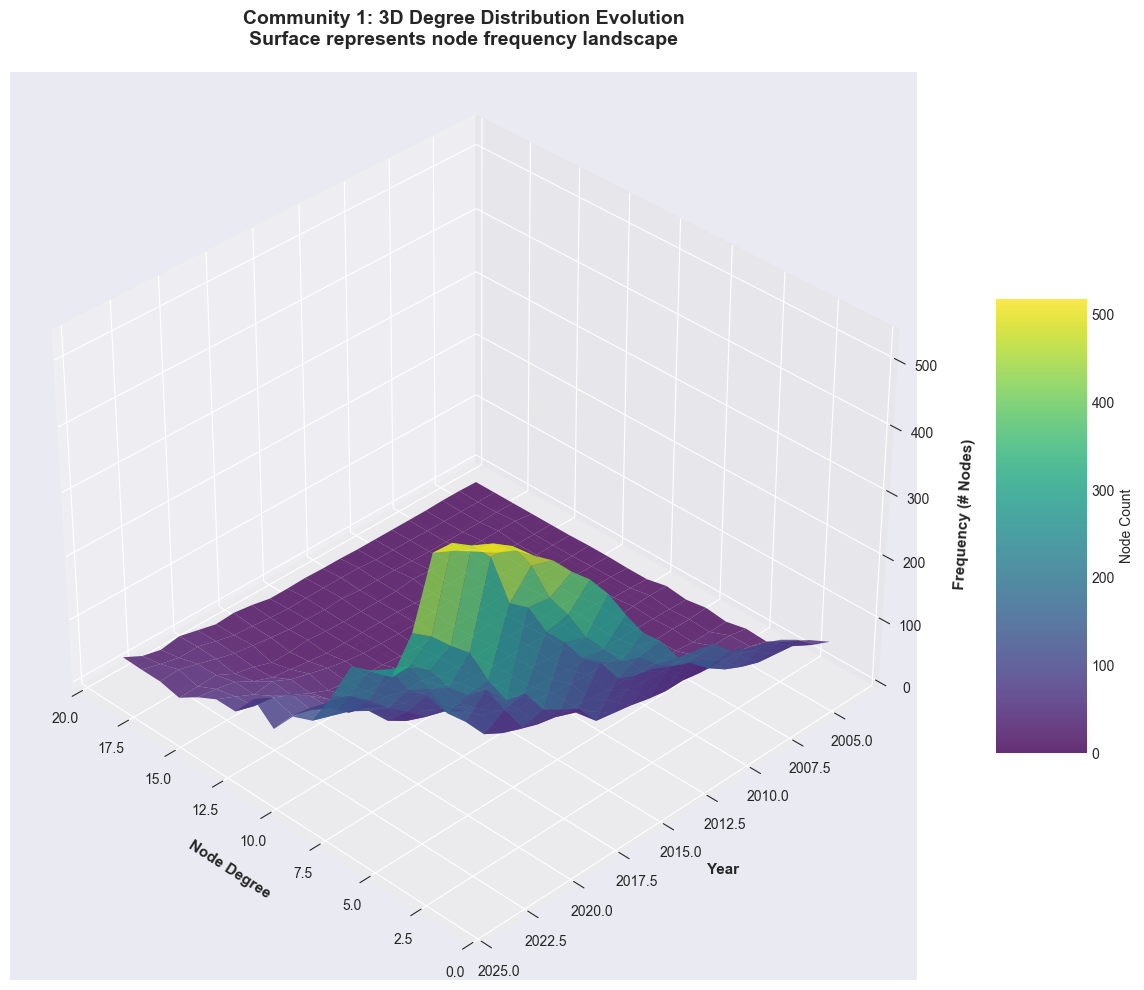

Community 1: 3D surface plots generated (2 views)


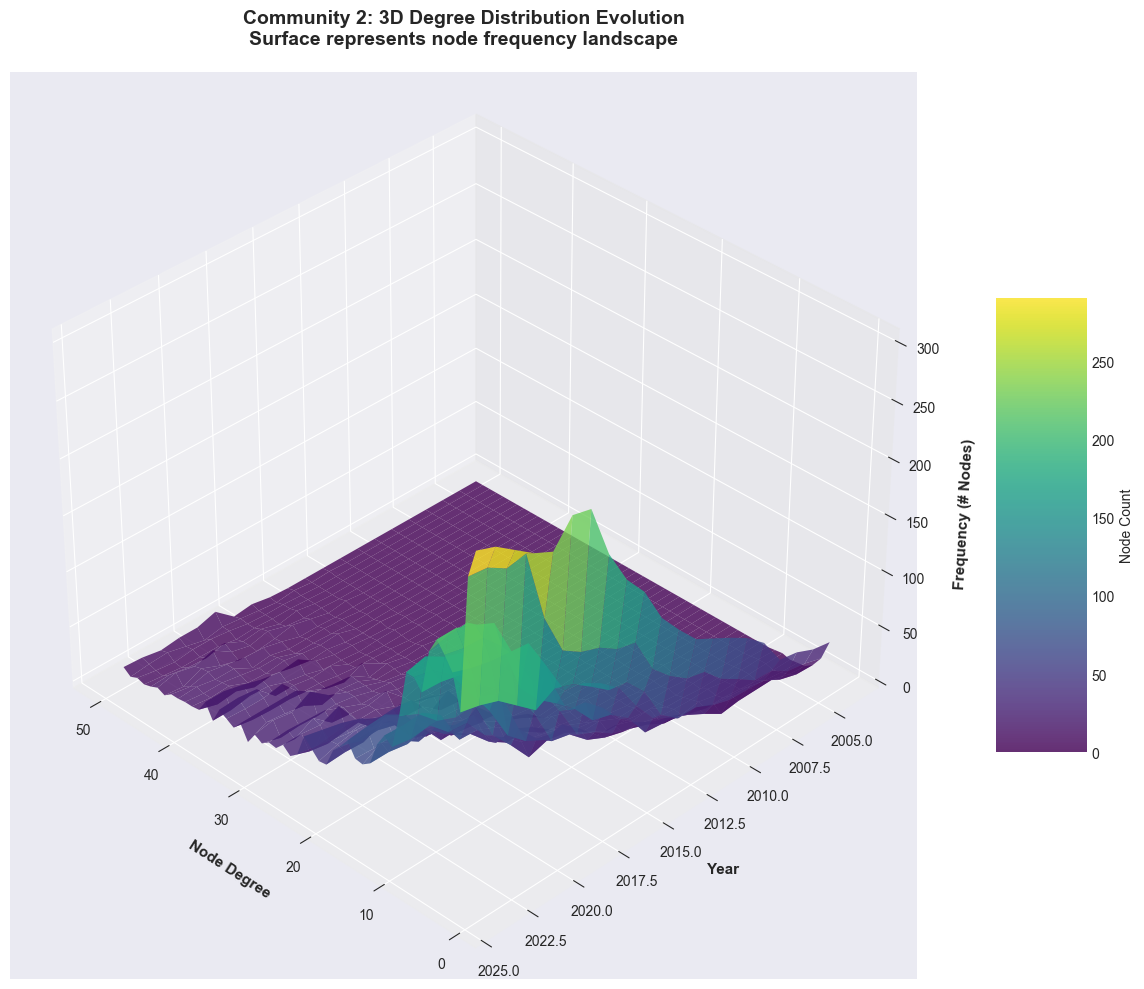

Community 2: 3D surface plots generated (2 views)


In [9]:
def create_3d_surface_plot(yearly_degrees, comm_id, figures_dir):
    """Create 3D surface plot of degree distribution evolution"""
    
    years_with_data = sorted([y for y in yearly_degrees[comm_id].keys() if len(yearly_degrees[comm_id][y]) > 5])
    
    if len(years_with_data) < 3:
        print(f"Community {comm_id}: Not enough data for 3D plot")
        return
    
    # Get degree range
    all_degrees = []
    for year in years_with_data:
        all_degrees.extend(yearly_degrees[comm_id][year].values())
    
    max_degree = min(int(np.percentile(all_degrees, 95)) + 1, 50)  # Use 95th percentile
    degree_range = np.arange(1, max_degree + 1)
    
    # Build surface data: rows=degrees, cols=years
    X = np.array(degree_range).reshape(-1, 1).repeat(len(years_with_data), axis=1)
    Z = np.array(years_with_data).reshape(1, -1).repeat(len(degree_range), axis=0)
    Y = np.zeros_like(X, dtype=float)
    
    for i, degree in enumerate(degree_range):
        for j, year in enumerate(years_with_data):
            degrees_in_year = yearly_degrees[comm_id][year].values()
            count = sum(1 for d in degrees_in_year if d == degree)
            Y[i, j] = count
    
    # Create figure
    fig = plt.figure(figsize=(16, 10))
    ax = fig.add_subplot(111, projection='3d')
    
    # Plot surface
    surf = ax.plot_surface(X, Z, Y, cmap='viridis', alpha=0.8, edgecolor='none')
    
    # Set labels
    ax.set_xlabel('Node Degree', fontsize=11, fontweight='bold', labelpad=10)
    ax.set_ylabel('Year', fontsize=11, fontweight='bold', labelpad=10)
    ax.set_zlabel('Frequency (# Nodes)', fontsize=11, fontweight='bold', labelpad=10)
    ax.set_title(f'Community {comm_id}: 3D Degree Distribution Evolution\nSurface represents node frequency landscape', 
                fontsize=14, fontweight='bold', pad=20)
    
    # Add colorbar
    fig.colorbar(surf, ax=ax, shrink=0.5, aspect=5, label='Node Count')
    
    # Set viewing angle
    ax.view_init(elev=25, azim=45)
    
    plt.tight_layout()
    plt.savefig(os.path.join(figures_dir, f'03_3d_surface_community_{comm_id}_view1.png'), dpi=300, bbox_inches='tight')
    
    # Alternative view angle
    ax.view_init(elev=35, azim=135)
    plt.savefig(os.path.join(figures_dir, f'03_3d_surface_community_{comm_id}_view2.png'), dpi=300, bbox_inches='tight')
    
    plt.show()
    
    print(f"Community {comm_id}: 3D surface plots generated (2 views)")

# Generate 3D surface plots for all communities
for comm_id in target_communities:
    create_3d_surface_plot(yearly_degrees, comm_id, figures_dir)

## Visualization 4: Violin Plots - Degree Distribution by Year

Shows statistical distribution of degrees across selected years.
Useful for comparing median, quartiles, and outliers across time.

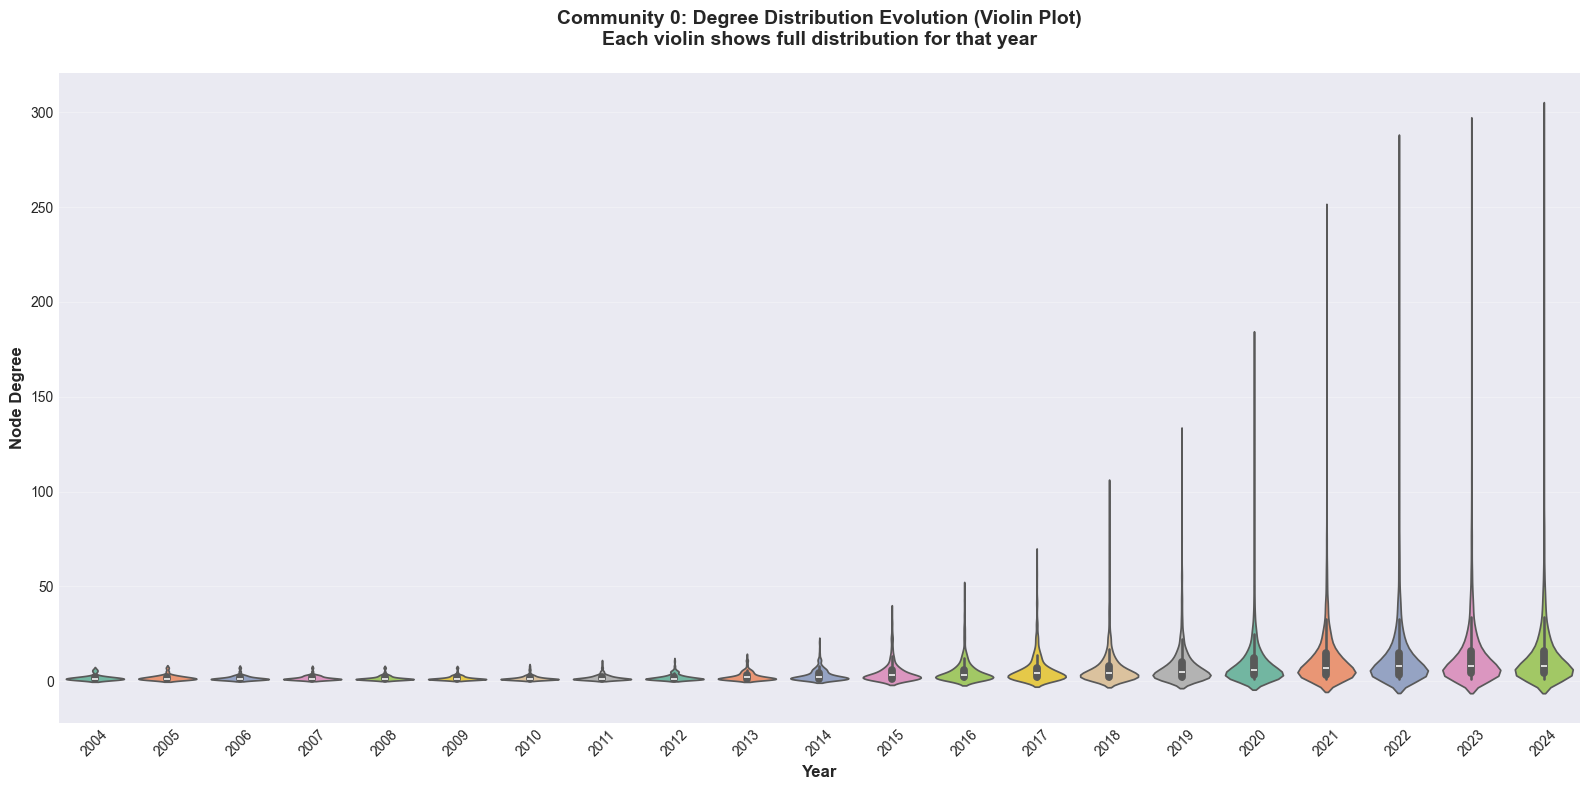

Community 0: Violin plot generated (21 years)


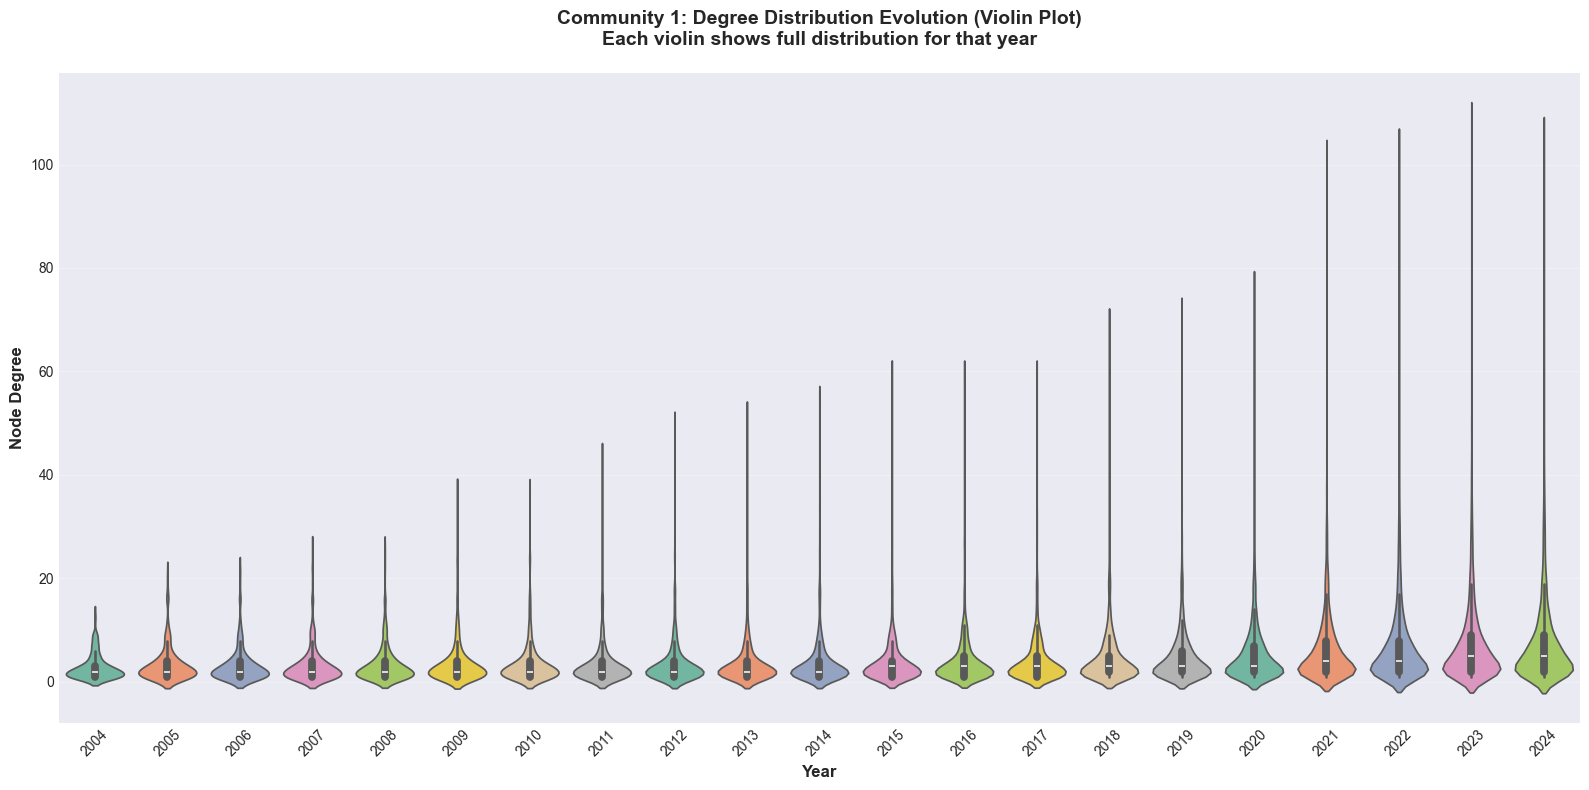

Community 1: Violin plot generated (21 years)


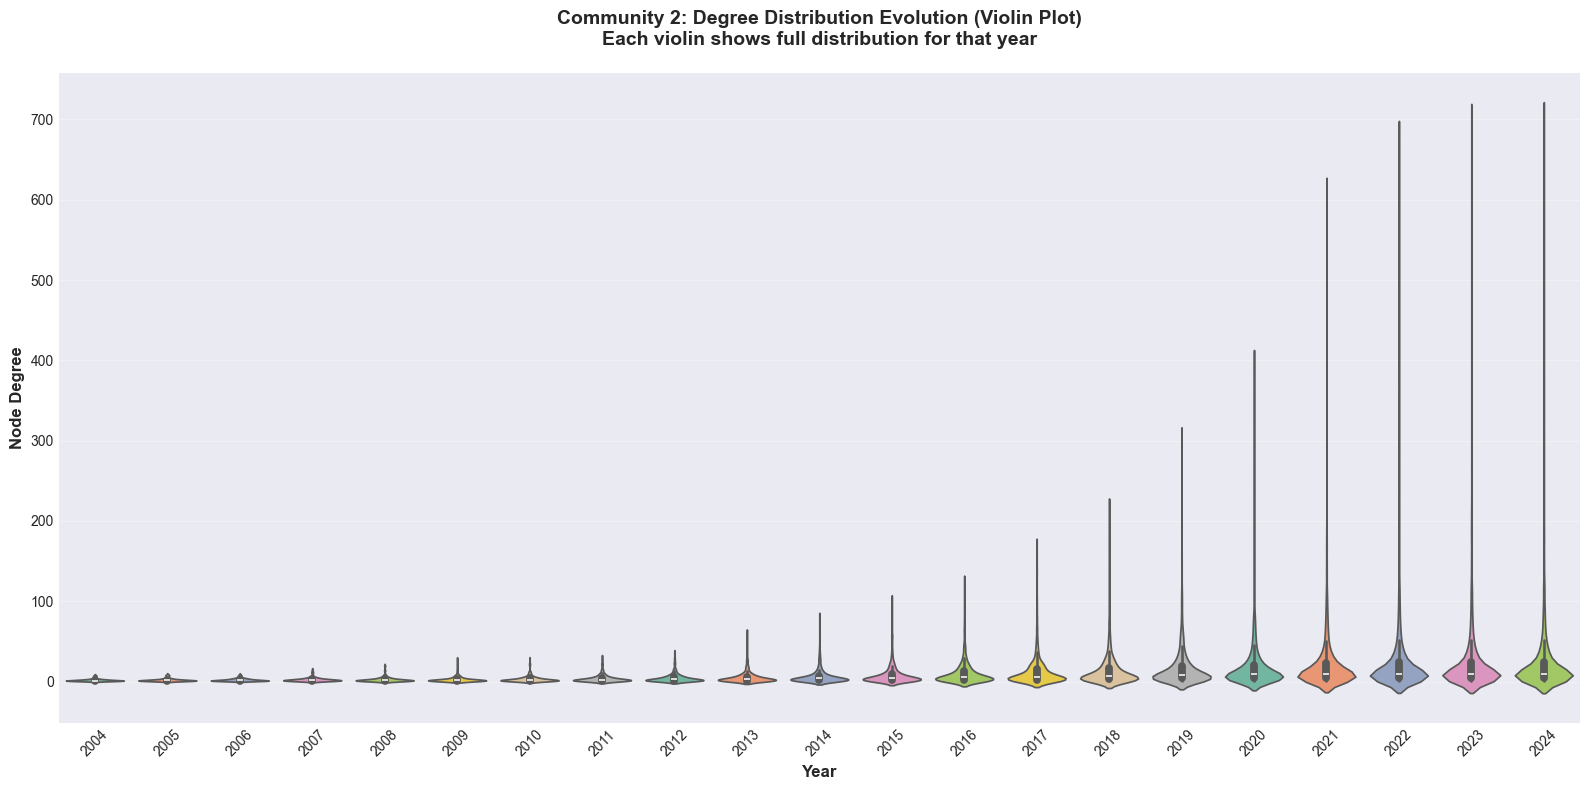

Community 2: Violin plot generated (21 years)


In [10]:
def create_violin_plots(yearly_degrees, comm_id, figures_dir):
    """Create violin plots of degree distribution by year"""
    
    years_with_data = sorted([y for y in yearly_degrees[comm_id].keys() if len(yearly_degrees[comm_id][y]) > 5])
    
    if len(years_with_data) < 3:
        print(f"Community {comm_id}: Not enough data for violin plot")
        return
    
    # Select every Nth year for clarity
    step = max(1, len(years_with_data) // 12)  # Show ~12 years
    selected_years = years_with_data[::step]
    if years_with_data[-1] not in selected_years:
        selected_years.append(years_with_data[-1])
    
    # Prepare data for violin plot
    plot_data = []
    for year in selected_years:
        degrees = list(yearly_degrees[comm_id][year].values())
        for degree in degrees:
            plot_data.append({'Year': year, 'Degree': degree})
    
    plot_df = pd.DataFrame(plot_data)
    
    # Create figure
    fig, ax = plt.subplots(figsize=(16, 8))
    
    # Create violin plot
    sns.violinplot(data=plot_df, x='Year', y='Degree', ax=ax, palette='Set2')
    
    ax.set_xlabel('Year', fontsize=12, fontweight='bold')
    ax.set_ylabel('Node Degree', fontsize=12, fontweight='bold')
    ax.set_title(f'Community {comm_id}: Degree Distribution Evolution (Violin Plot)\nEach violin shows full distribution for that year', 
                fontsize=14, fontweight='bold', pad=20)
    ax.grid(True, alpha=0.3, axis='y')
    
    # Rotate x labels
    plt.xticks(rotation=45)
    
    plt.tight_layout()
    plt.savefig(os.path.join(figures_dir, f'04_violin_plot_community_{comm_id}.png'), dpi=300, bbox_inches='tight')
    plt.show()
    
    print(f"Community {comm_id}: Violin plot generated ({len(selected_years)} years)")

# Generate violin plots for all communities
for comm_id in target_communities:
    create_violin_plots(yearly_degrees, comm_id, figures_dir)

## Visualization 5: Statistical Metrics Evolution

Track how statistical properties of degree distributions evolve over time:
- Mean degree
- Median degree
- Standard deviation
- Skewness
- Gini coefficient (inequality)

In [11]:
def calculate_gini(x):
    """Calculate Gini coefficient for degree inequality"""
    x = np.asarray(x)
    if len(x) == 0:
        return np.nan
    x = np.sort(x)
    n = len(x)
    return (2 * np.sum((n - np.arange(1, n+1) + 1) * x)) / (n * np.sum(x)) - (n + 1) / n

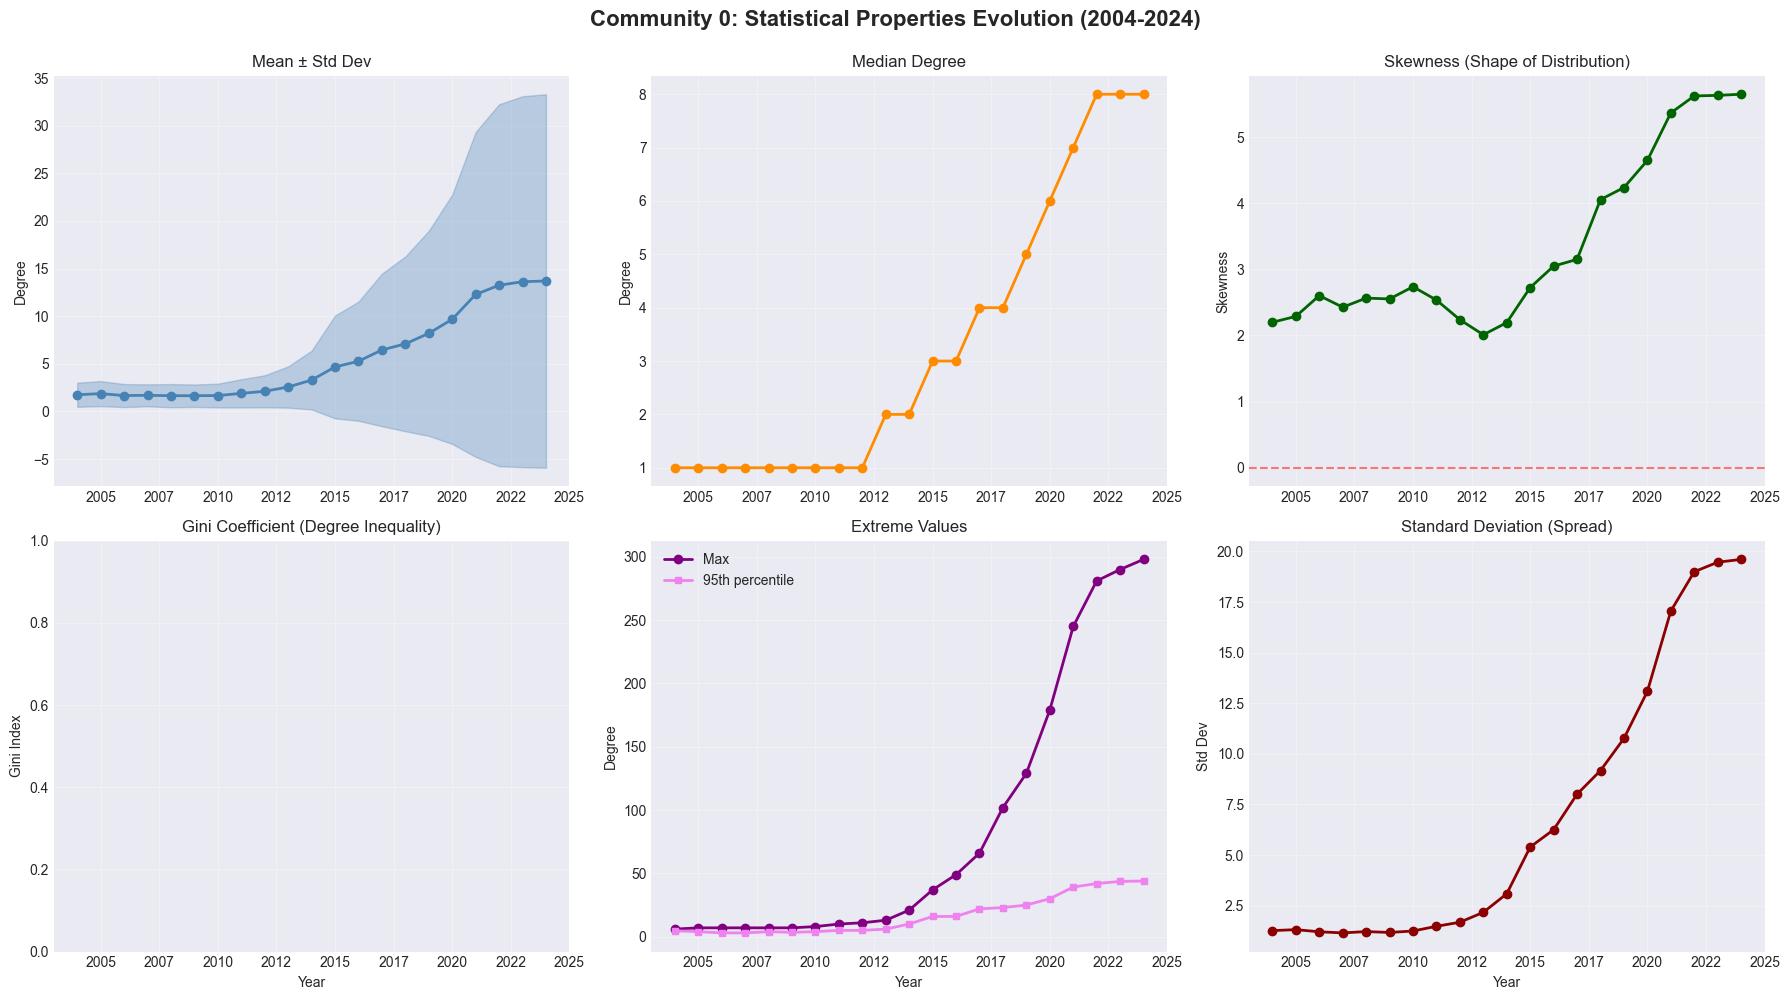

Community 0: Statistics evolution plot generated


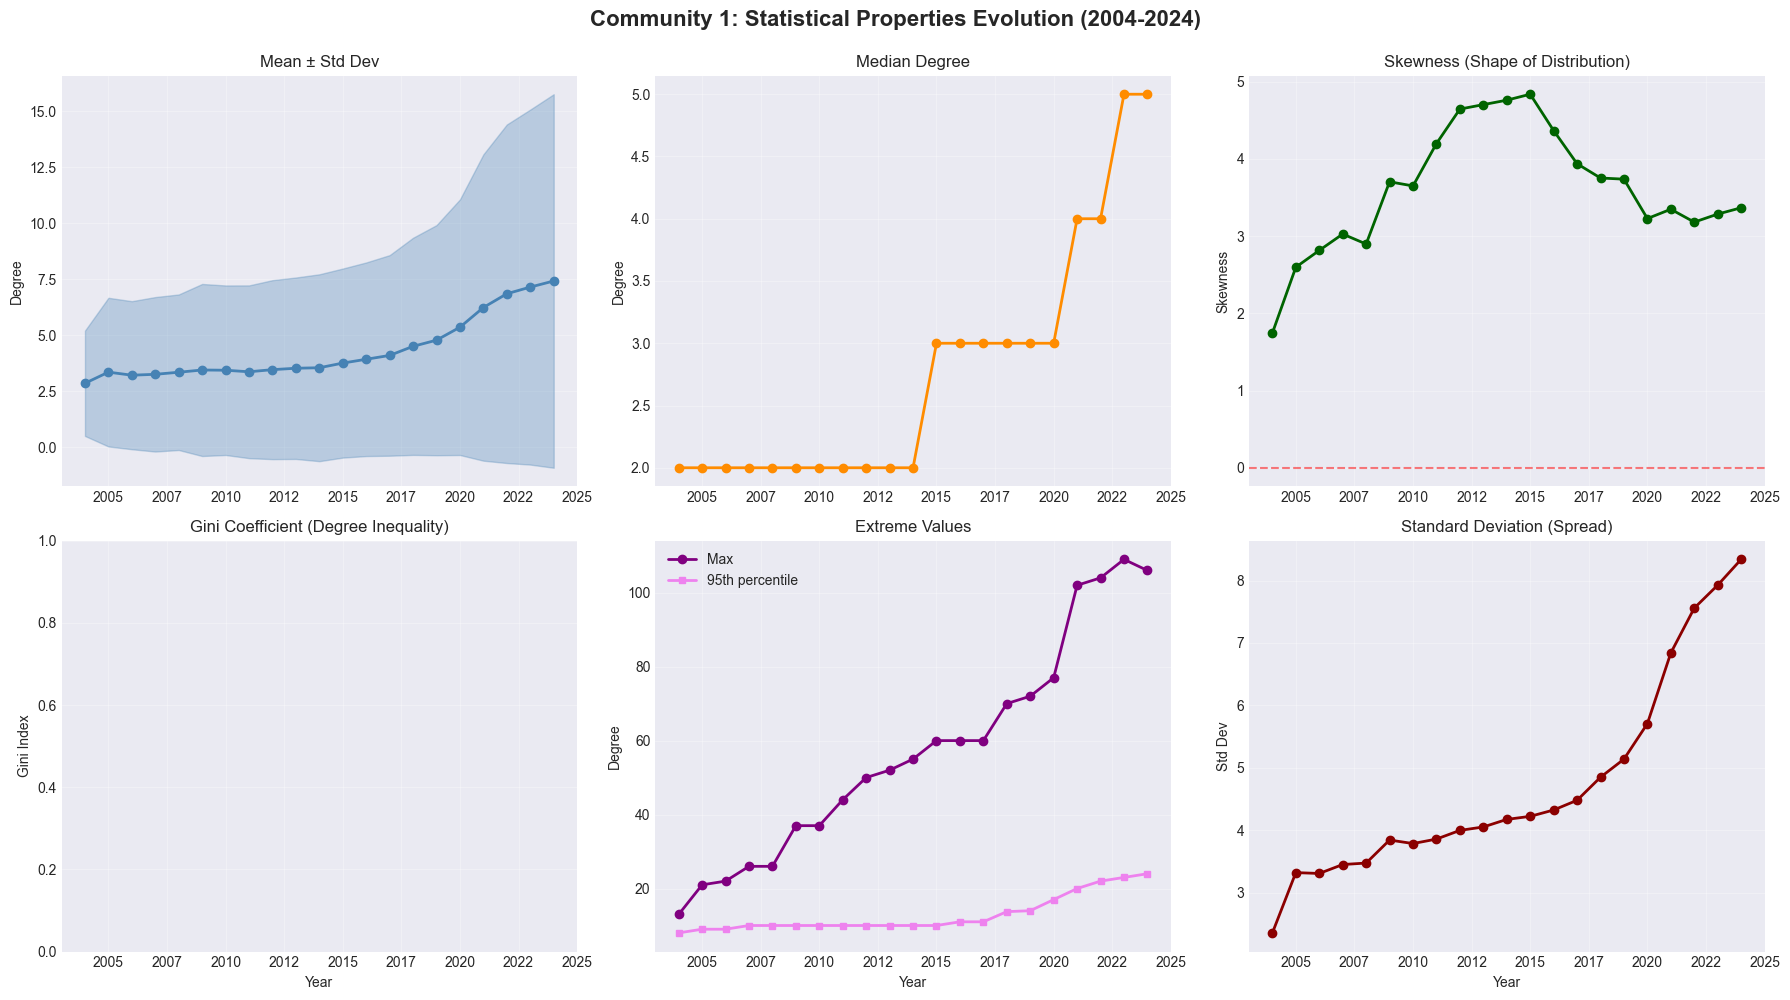

Community 1: Statistics evolution plot generated


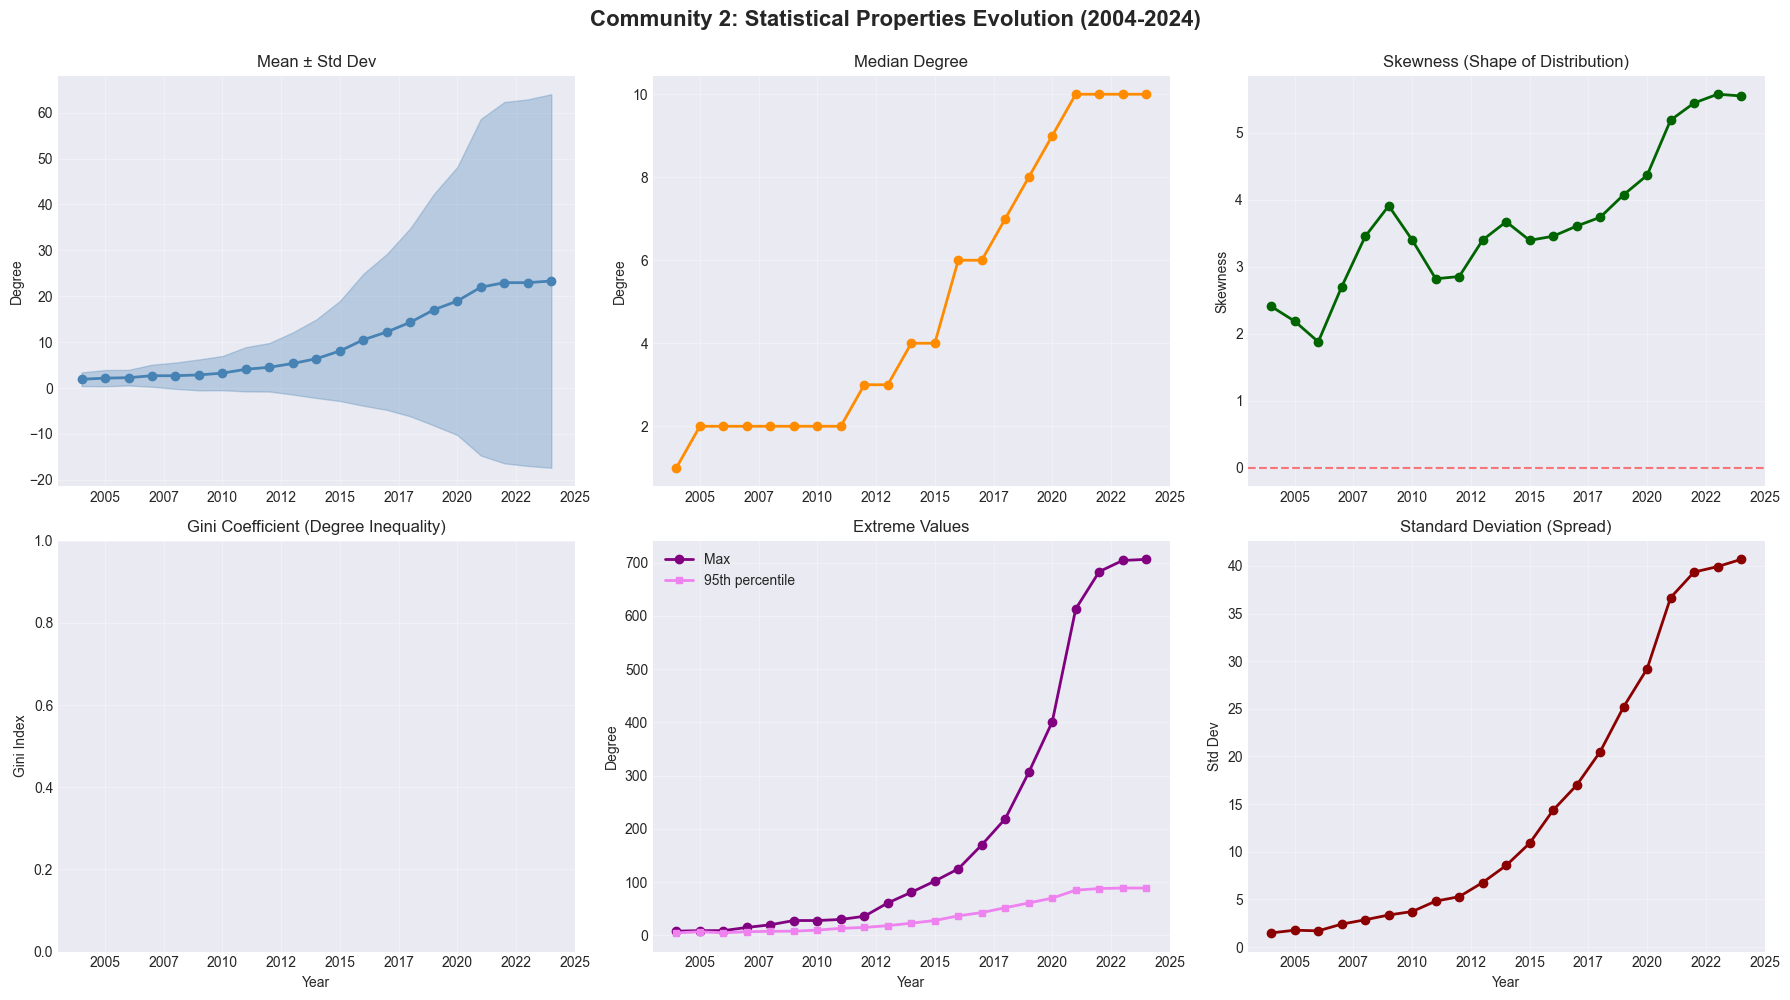

Community 2: Statistics evolution plot generated


In [12]:
def create_statistics_evolution_plot(yearly_degrees, comm_id, figures_dir):
    """Create plot of statistical metrics evolution"""
    
    years_with_data = sorted([y for y in yearly_degrees[comm_id].keys() if len(yearly_degrees[comm_id][y]) > 5])
    
    if len(years_with_data) < 3:
        print(f"Community {comm_id}: Not enough data for statistics evolution plot")
        return
    
    # Calculate statistics for each year
    stats_data = {
        'year': [],
        'mean': [],
        'median': [],
        'std': [],
        'skewness': [],
        'gini': [],
        'max_degree': [],
        'percentile_95': []
    }
    
    for year in years_with_data:
        degrees = np.array(list(yearly_degrees[comm_id][year].values()))
        
        stats_data['year'].append(year)
        stats_data['mean'].append(np.mean(degrees))
        stats_data['median'].append(np.median(degrees))
        stats_data['std'].append(np.std(degrees))
        stats_data['skewness'].append(stats.skew(degrees))
        stats_data['gini'].append(calculate_gini(degrees))
        stats_data['max_degree'].append(np.max(degrees))
        stats_data['percentile_95'].append(np.percentile(degrees, 95))
    
    stats_df = pd.DataFrame(stats_data)
    
    # Create figure with subplots
    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    fig.suptitle(f'Community {comm_id}: Statistical Properties Evolution (2004-2024)', 
                fontsize=16, fontweight='bold', y=0.995)
    
    # Plot 1: Mean degree
    axes[0, 0].plot(stats_df['year'], stats_df['mean'], 'o-', linewidth=2, markersize=6, color='steelblue')
    axes[0, 0].fill_between(stats_df['year'], stats_df['mean'] - stats_df['std'], stats_df['mean'] + stats_df['std'], alpha=0.3, color='steelblue')
    axes[0, 0].set_title('Mean ± Std Dev')
    axes[0, 0].set_ylabel('Degree')
    axes[0, 0].grid(True, alpha=0.3)
    
    # Plot 2: Median degree
    axes[0, 1].plot(stats_df['year'], stats_df['median'], 'o-', linewidth=2, markersize=6, color='darkorange')
    axes[0, 1].set_title('Median Degree')
    axes[0, 1].set_ylabel('Degree')
    axes[0, 1].grid(True, alpha=0.3)
    
    # Plot 3: Skewness
    axes[0, 2].plot(stats_df['year'], stats_df['skewness'], 'o-', linewidth=2, markersize=6, color='darkgreen')
    axes[0, 2].axhline(y=0, color='red', linestyle='--', alpha=0.5)
    axes[0, 2].set_title('Skewness (Shape of Distribution)')
    axes[0, 2].set_ylabel('Skewness')
    axes[0, 2].grid(True, alpha=0.3)
    
    # Plot 4: Gini coefficient
    axes[1, 0].plot(stats_df['year'], stats_df['gini'], 'o-', linewidth=2, markersize=6, color='darkred')
    axes[1, 0].set_title('Gini Coefficient (Degree Inequality)')
    axes[1, 0].set_ylabel('Gini Index')
    axes[1, 0].set_xlabel('Year')
    axes[1, 0].set_ylim([0, 1])
    axes[1, 0].grid(True, alpha=0.3)
    
    # Plot 5: Max and 95th percentile
    axes[1, 1].plot(stats_df['year'], stats_df['max_degree'], 'o-', linewidth=2, markersize=6, label='Max', color='purple')
    axes[1, 1].plot(stats_df['year'], stats_df['percentile_95'], 's-', linewidth=2, markersize=5, label='95th percentile', color='violet')
    axes[1, 1].set_title('Extreme Values')
    axes[1, 1].set_ylabel('Degree')
    axes[1, 1].set_xlabel('Year')
    axes[1, 1].legend()
    axes[1, 1].grid(True, alpha=0.3)
    
    # Plot 6: Standard deviation trend
    axes[1, 2].plot(stats_df['year'], stats_df['std'], 'o-', linewidth=2, markersize=6, color='darkred')
    axes[1, 2].set_title('Standard Deviation (Spread)')
    axes[1, 2].set_ylabel('Std Dev')
    axes[1, 2].set_xlabel('Year')
    axes[1, 2].grid(True, alpha=0.3)
    
    for i in range(2):
        for j in range(3):
            axes[i, j].xaxis.set_major_formatter(plt.FormatStrFormatter('%d'))
    
    plt.tight_layout()
    plt.savefig(os.path.join(figures_dir, f'05_statistics_evolution_community_{comm_id}.png'), dpi=300, bbox_inches='tight')
    plt.show()
    
    print(f"Community {comm_id}: Statistics evolution plot generated")
    
    return stats_df

# Generate statistics plots for all communities
stats_results = {}
for comm_id in target_communities:
    stats_results[comm_id] = create_statistics_evolution_plot(yearly_degrees, comm_id, figures_dir)

## Visualization 6: Grid of Year-by-Year Histograms

Shows individual degree distribution histograms for key years.
Useful for seeing detailed distribution shape at specific time points.

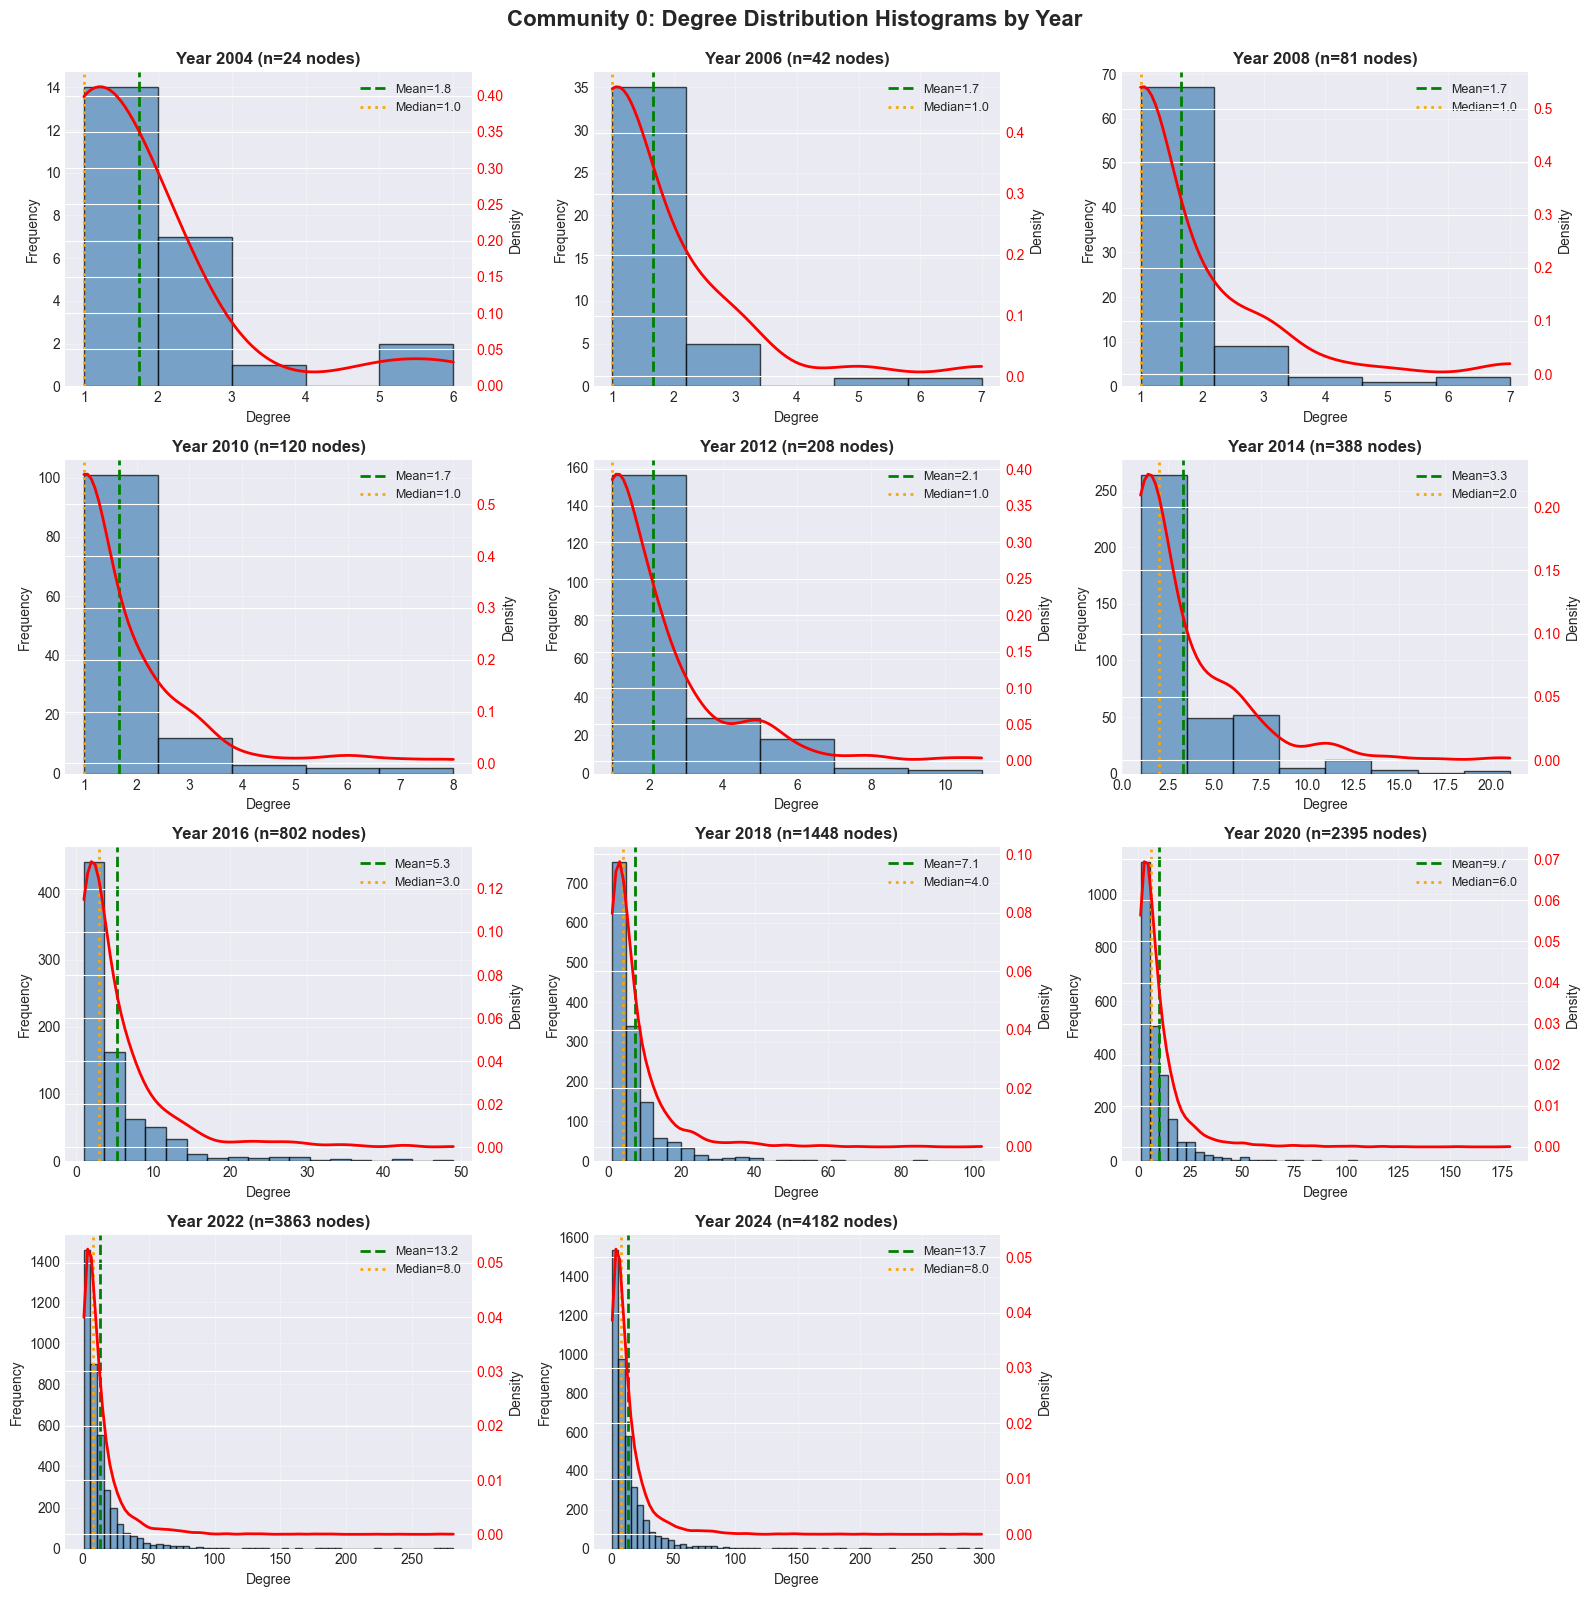

Community 0: Histogram grid generated (11 years)


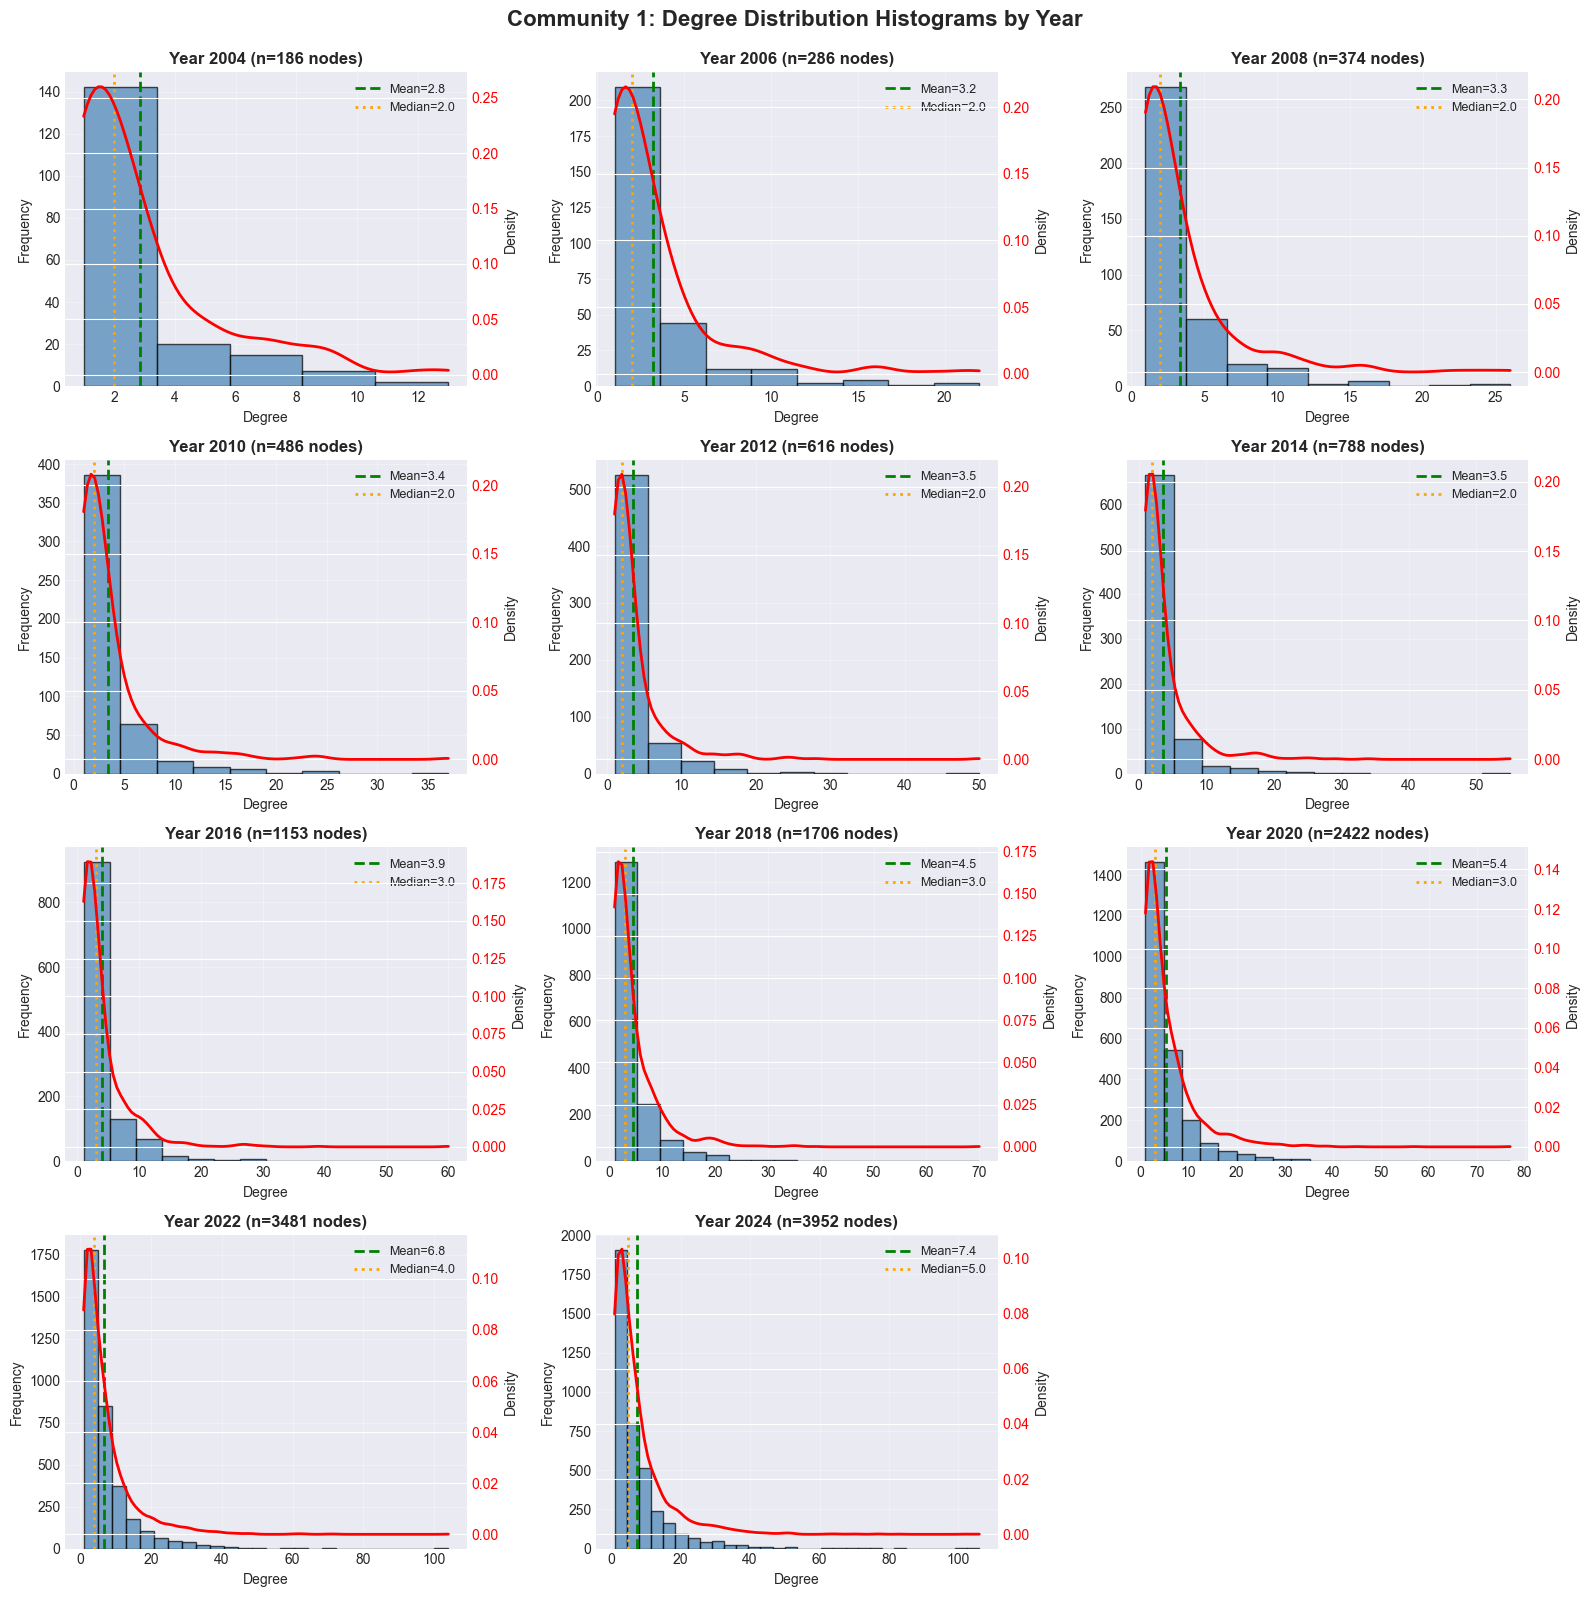

Community 1: Histogram grid generated (11 years)


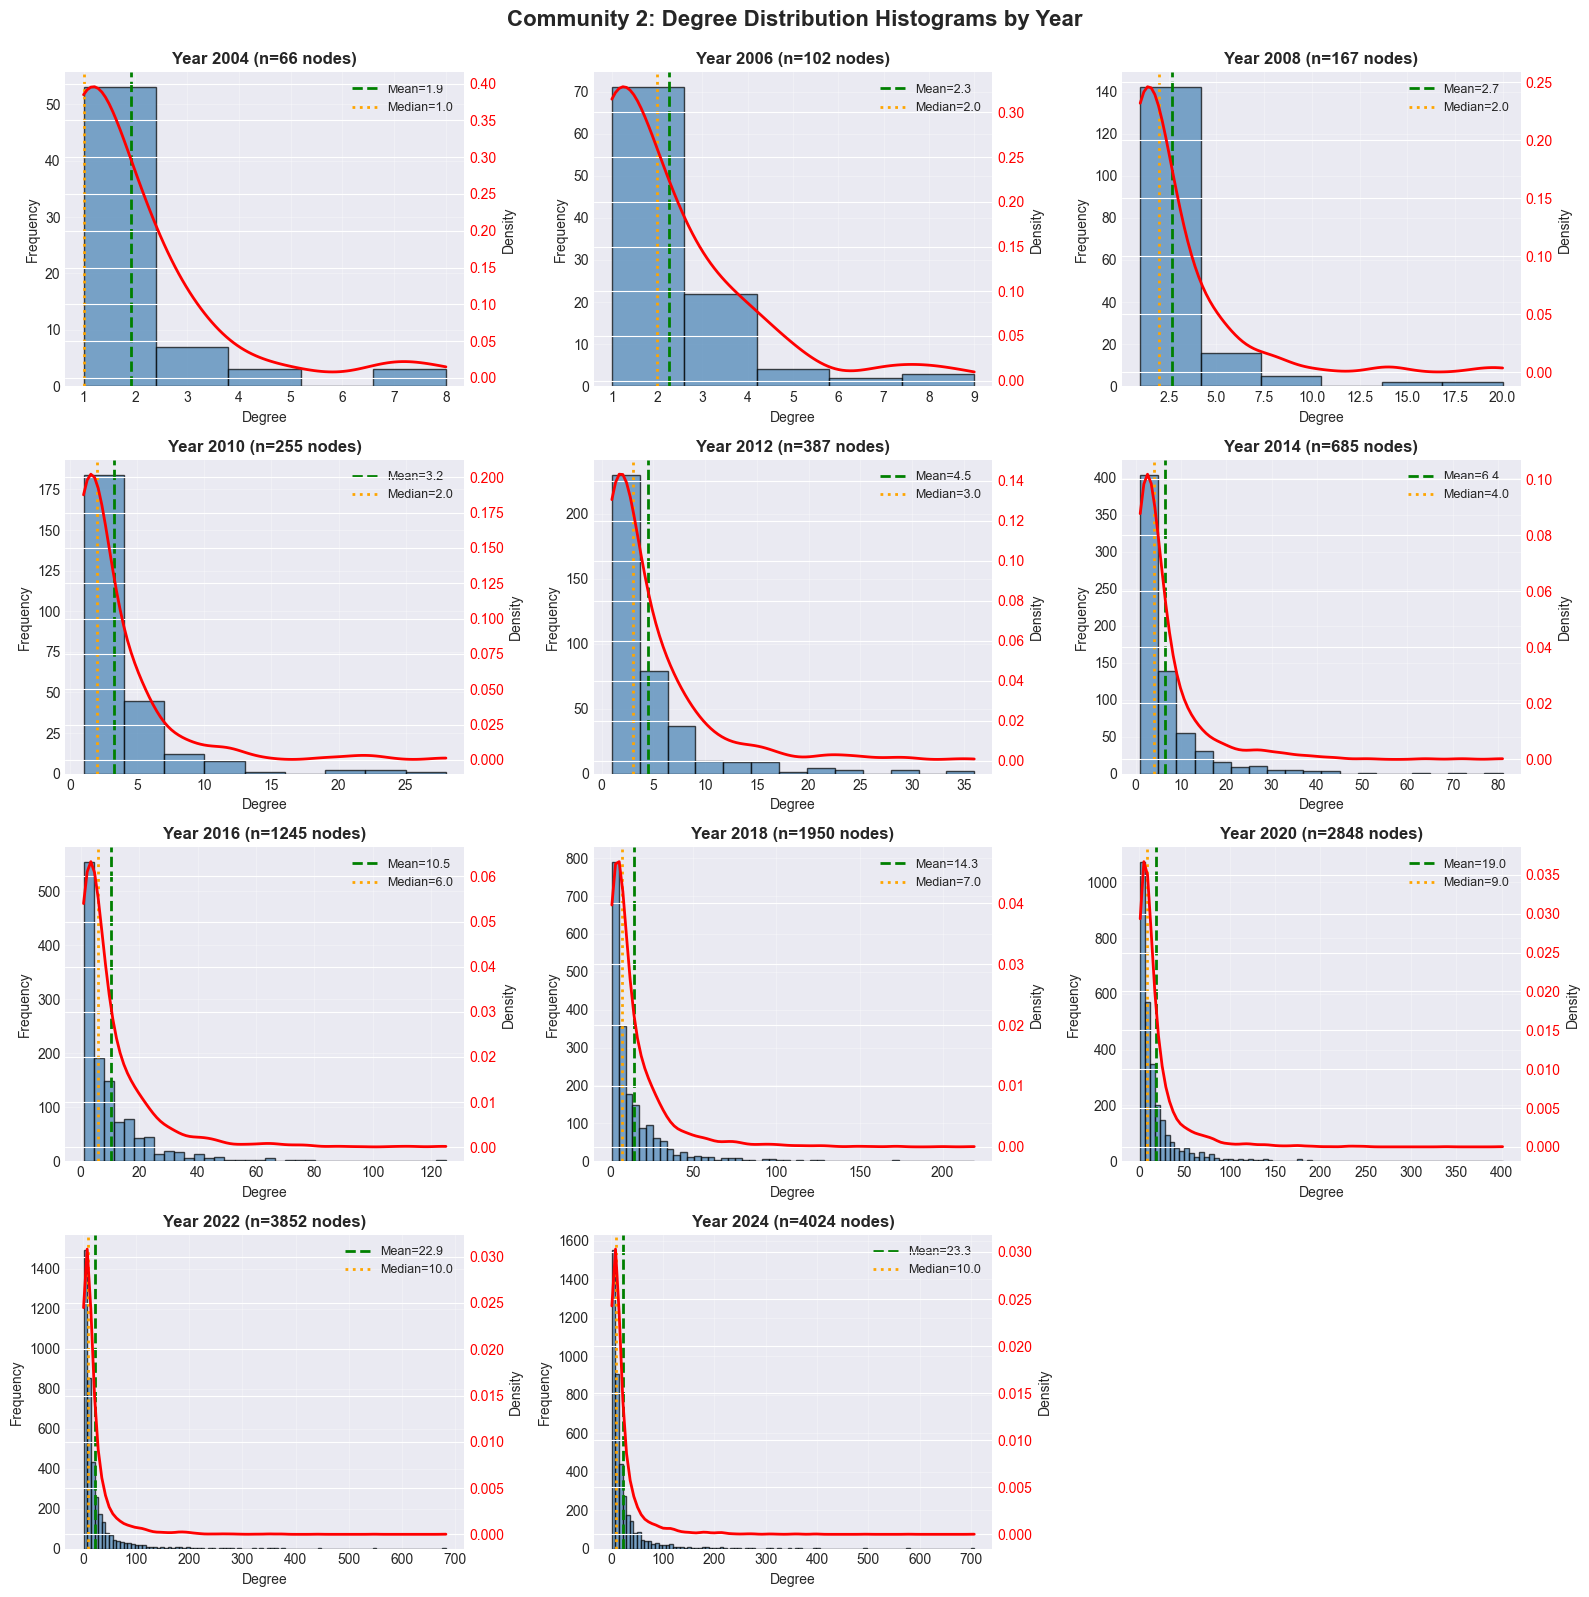

Community 2: Histogram grid generated (11 years)


In [13]:
def create_histogram_grid(yearly_degrees, comm_id, figures_dir):
    """Create grid of histograms for selected years"""
    
    years_with_data = sorted([y for y in yearly_degrees[comm_id].keys() if len(yearly_degrees[comm_id][y]) > 5])
    
    if len(years_with_data) < 4:
        print(f"Community {comm_id}: Not enough data for histogram grid")
        return
    
    # Select every Nth year evenly spaced
    step = max(1, len(years_with_data) // 9)  # 9 subplots (3x3)
    selected_years = years_with_data[::step]
    if years_with_data[-1] not in selected_years and len(selected_years) < 9:
        selected_years.append(years_with_data[-1])
    
    n_plots = len(selected_years)
    n_cols = 3
    n_rows = (n_plots + n_cols - 1) // n_cols
    
    # Create figure
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 4*n_rows))
    axes = axes.flatten()  # Flatten to 1D for easier indexing
    
    fig.suptitle(f'Community {comm_id}: Degree Distribution Histograms by Year', 
                fontsize=16, fontweight='bold', y=0.995)
    
    for idx, year in enumerate(selected_years):
        degrees = np.array(list(yearly_degrees[comm_id][year].values()))
        
        ax = axes[idx]
        
        # Histogram
        ax.hist(degrees, bins=max(5, len(set(degrees))//2), alpha=0.7, color='steelblue', edgecolor='black')
        
        # Add KDE
        if len(degrees) > 1:
            kde = gaussian_kde(degrees)
            x_range = np.linspace(degrees.min(), degrees.max(), 100)
            ax2 = ax.twinx()
            ax2.plot(x_range, kde(x_range), 'r-', linewidth=2, label='KDE')
            ax2.set_ylabel('Density', fontsize=10)
            ax2.tick_params(axis='y', labelcolor='red')
        
        # Statistics
        mean_deg = np.mean(degrees)
        median_deg = np.median(degrees)
        std_deg = np.std(degrees)
        
        ax.axvline(mean_deg, color='green', linestyle='--', linewidth=2, label=f'Mean={mean_deg:.1f}')
        ax.axvline(median_deg, color='orange', linestyle=':', linewidth=2, label=f'Median={median_deg:.1f}')
        
        ax.set_title(f'Year {year} (n={len(degrees)} nodes)', fontweight='bold')
        ax.set_xlabel('Degree')
        ax.set_ylabel('Frequency')
        ax.legend(loc='upper right', fontsize=9)
        ax.grid(True, alpha=0.3)
    
    # Hide unused subplots
    for idx in range(n_plots, len(axes)):
        axes[idx].set_visible(False)
    
    plt.tight_layout()
    plt.savefig(os.path.join(figures_dir, f'06_histogram_grid_community_{comm_id}.png'), dpi=300, bbox_inches='tight')
    plt.show()
    
    print(f"Community {comm_id}: Histogram grid generated ({n_plots} years)")

# Generate histogram grids for all communities
for comm_id in target_communities:
    create_histogram_grid(yearly_degrees, comm_id, figures_dir)

## Visualization 7: Comparative Analysis - All Communities

Compare degree distribution metrics across all three communities over time.

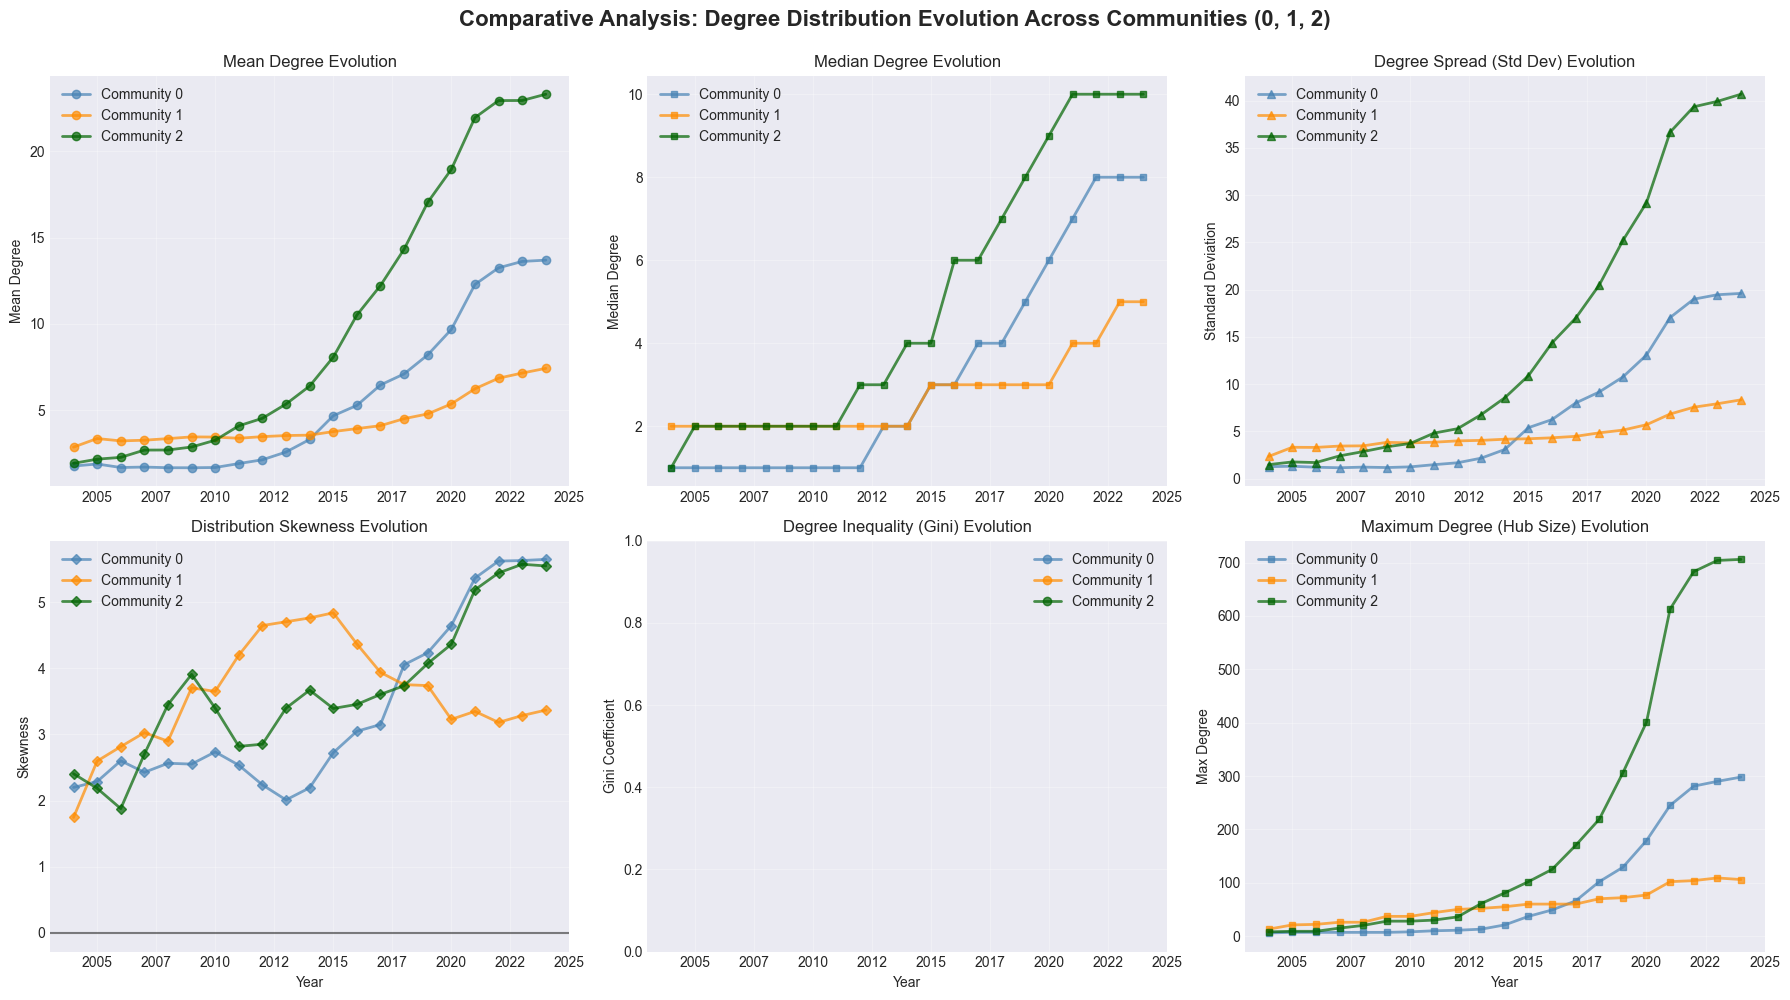

Comparative analysis plot generated


In [14]:
# Create comparative plots across communities
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Comparative Analysis: Degree Distribution Evolution Across Communities (0, 1, 2)', 
            fontsize=16, fontweight='bold', y=0.995)

colors = {0: 'steelblue', 1: 'darkorange', 2: 'darkgreen'}

for comm_id in target_communities:
    if comm_id not in stats_results:
        continue
    
    stats_df = stats_results[comm_id]
    color = colors[comm_id]
    
    # Plot 1: Mean degree comparison
    axes[0, 0].plot(stats_df['year'], stats_df['mean'], 'o-', linewidth=2, markersize=6, 
                   label=f'Community {comm_id}', color=color, alpha=0.7)
    axes[0, 0].set_title('Mean Degree Evolution')
    axes[0, 0].set_ylabel('Mean Degree')
    axes[0, 0].legend()
    axes[0, 0].grid(True, alpha=0.3)
    
    # Plot 2: Median degree comparison
    axes[0, 1].plot(stats_df['year'], stats_df['median'], 's-', linewidth=2, markersize=5, 
                   label=f'Community {comm_id}', color=color, alpha=0.7)
    axes[0, 1].set_title('Median Degree Evolution')
    axes[0, 1].set_ylabel('Median Degree')
    axes[0, 1].legend()
    axes[0, 1].grid(True, alpha=0.3)
    
    # Plot 3: Std dev comparison
    axes[0, 2].plot(stats_df['year'], stats_df['std'], '^-', linewidth=2, markersize=6, 
                   label=f'Community {comm_id}', color=color, alpha=0.7)
    axes[0, 2].set_title('Degree Spread (Std Dev) Evolution')
    axes[0, 2].set_ylabel('Standard Deviation')
    axes[0, 2].legend()
    axes[0, 2].grid(True, alpha=0.3)
    
    # Plot 4: Skewness comparison
    axes[1, 0].plot(stats_df['year'], stats_df['skewness'], 'D-', linewidth=2, markersize=5, 
                   label=f'Community {comm_id}', color=color, alpha=0.7)
    axes[1, 0].axhline(y=0, color='black', linestyle='-', alpha=0.2)
    axes[1, 0].set_title('Distribution Skewness Evolution')
    axes[1, 0].set_ylabel('Skewness')
    axes[1, 0].set_xlabel('Year')
    axes[1, 0].legend()
    axes[1, 0].grid(True, alpha=0.3)
    
    # Plot 5: Gini coefficient comparison
    axes[1, 1].plot(stats_df['year'], stats_df['gini'], 'o-', linewidth=2, markersize=6, 
                   label=f'Community {comm_id}', color=color, alpha=0.7)
    axes[1, 1].set_title('Degree Inequality (Gini) Evolution')
    axes[1, 1].set_ylabel('Gini Coefficient')
    axes[1, 1].set_xlabel('Year')
    axes[1, 1].set_ylim([0, 1])
    axes[1, 1].legend()
    axes[1, 1].grid(True, alpha=0.3)
    
    # Plot 6: Max degree comparison
    axes[1, 2].plot(stats_df['year'], stats_df['max_degree'], 's-', linewidth=2, markersize=5, 
                   label=f'Community {comm_id}', color=color, alpha=0.7)
    axes[1, 2].set_title('Maximum Degree (Hub Size) Evolution')
    axes[1, 2].set_ylabel('Max Degree')
    axes[1, 2].set_xlabel('Year')
    axes[1, 2].legend()
    axes[1, 2].grid(True, alpha=0.3)

# Set x-axis format for all plots
for i in range(2):
    for j in range(3):
        axes[i, j].xaxis.set_major_formatter(plt.FormatStrFormatter('%d'))

plt.tight_layout()
plt.savefig(os.path.join(figures_dir, '07_comparative_analysis_all_communities.png'), dpi=300, bbox_inches='tight')
plt.show()

print("Comparative analysis plot generated")

## Section 8: Comparative Network Analysis - Dissortativity & Structural Causes

### Overview
This section investigates why Community 2 exhibits stronger dissortativity (negative assortativity)
compared to Communities 0 and 1. We examine:
- **Degree variance** and inequality (Gini coefficient)
- **Power-law tail exponents** for heavy-tailed distributions
- **Assortativity coefficients** and their temporal evolution
- **Structural factors** that explain dissortativity differences
- **Network composition** (hub vs regular nodes, bipartite balance)

In [15]:
from scipy.optimize import curve_fit
from scipy.stats import linregress, spearmanr, pearsonr
import matplotlib.patches as mpatches

print("Imports for comparative analysis loaded")

Imports for comparative analysis loaded


### Power-Law Analysis and Heavy-Tail Behavior

In [16]:
def fit_power_law(degrees, min_degree=1):
    """
    Fit power-law distribution to degree tail and calculate exponent.
    Returns: (exponent, r_squared, threshold_degree)"
    """
    degrees = np.array(degrees)
    degrees = degrees[degrees >= min_degree]
    
    if len(degrees) < 10:
        return np.nan, np.nan, np.nan
    
    # Use only upper tail (top 25%) for better fit
    threshold = np.percentile(degrees, 75)
    tail_degrees = degrees[degrees >= threshold]
    
    if len(tail_degrees) < 5:
        return np.nan, np.nan, np.nan
    
    # Fit log-log relationship: log(P(k)) = -alpha * log(k) + c
    log_degrees = np.log(tail_degrees)
    
    # Create frequency distribution
    unique_degrees, counts = np.unique(tail_degrees, return_counts=True)
    degree_dist = counts / len(tail_degrees)
    
    log_unique = np.log(unique_degrees)
    log_dist = np.log(degree_dist + 1e-6)  # Add small value to avoid log(0)
    
    # Linear regression on log-log data
    slope, intercept, r_value, p_value, std_err = linregress(log_unique, log_dist)
    
    # Power-law exponent is the negative slope
    alpha = -slope
    
    return alpha, r_value**2, threshold

def calculate_assortativity(G):
    """Calculate assortativity coefficient (Pearson correlation of neighbor degrees)"""
    if len(G) < 2:
        return np.nan
    try:
        return nx.degree_assortativity_coefficient(G)
    except:
        return np.nan

def calculate_gini_coefficient(degrees):
    """Calculate Gini coefficient for degree distribution"""
    degrees = np.asarray(degrees)
    if len(degrees) == 0:
        return np.nan
    degrees = np.sort(degrees)
    n = len(degrees)
    cum_sum = np.cumsum(degrees)
    return (2 * np.sum(np.arange(1, n+1) * degrees)) / (n * cum_sum[-1]) - (n + 1) / n

def calculate_variance_ratio(degrees):
    """
    Calculate variance-to-mean ratio (dispersion index).
    High values indicate presence of hubs."
    """
    degrees = np.asarray(degrees)
    if len(degrees) < 2:
        return np.nan
    mean = np.mean(degrees)
    if mean == 0:
        return np.nan
    variance = np.var(degrees)
    return variance / mean

def calculate_coefficient_of_variation(degrees):
    """Calculate CV (std/mean) - normalized spread measure"""
    degrees = np.asarray(degrees)
    mean = np.mean(degrees)
    if mean == 0:
        return np.nan
    return np.std(degrees) / mean

print("Power-law analysis functions defined")

Power-law analysis functions defined


In [17]:
# Calculate comprehensive metrics for each community across time
comparative_metrics = {}

print("Computing comparative metrics for all communities...\n")
print("="*80)

for comm_id in target_communities:
    years_with_data = sorted([y for y in yearly_degrees[comm_id].keys() if len(yearly_degrees[comm_id][y]) > 5])
    
    metrics_data = {
        'year': [],
        'n_nodes': [],
        'n_edges': [],
        'density': [],
        'mean_degree': [],
        'median_degree': [],
        'std_degree': [],
        'gini': [],
        'variance_ratio': [],
        'cv': [],
        'power_law_alpha': [],
        'power_law_r2': [],
        'assortativity': [],
        'clustering_coeff': [],
        'degree_max': [],
        'degree_p90': [],
        'hub_count': [],  # nodes with degree > mean + std
        'hub_proportion': []
    }
    
    for year in years_with_data:
        if year not in yearly_graphs[comm_id]:
            continue
        
        G = yearly_graphs[comm_id][year]
        degrees = np.array(list(yearly_degrees[comm_id][year].values()))
        
        n_nodes = G.number_of_nodes()
        n_edges = G.number_of_edges()
        possible_edges = n_nodes * (n_nodes - 1) / 2 if n_nodes > 1 else 0
        density = n_edges / possible_edges if possible_edges > 0 else 0
        
        # Basic statistics
        mean_deg = np.mean(degrees)
        median_deg = np.median(degrees)
        std_deg = np.std(degrees)
        
        # Inequality measures
        gini = calculate_gini_coefficient(degrees)
        var_ratio = calculate_variance_ratio(degrees)
        cv = calculate_coefficient_of_variation(degrees)
        
        # Power-law
        alpha, r2, threshold = fit_power_law(degrees)
        
        # Network properties
        assortativity = calculate_assortativity(G)
        clustering = nx.average_clustering(G) if n_nodes > 1 else 0
        
        # Hub analysis
        hub_threshold = mean_deg + std_deg if std_deg > 0 else mean_deg * 1.5
        hub_count = np.sum(degrees > hub_threshold)
        hub_prop = hub_count / n_nodes if n_nodes > 0 else 0
        
        # Store metrics
        metrics_data['year'].append(year)
        metrics_data['n_nodes'].append(n_nodes)
        metrics_data['n_edges'].append(n_edges)
        metrics_data['density'].append(density)
        metrics_data['mean_degree'].append(mean_deg)
        metrics_data['median_degree'].append(median_deg)
        metrics_data['std_degree'].append(std_deg)
        metrics_data['gini'].append(gini)
        metrics_data['variance_ratio'].append(var_ratio)
        metrics_data['cv'].append(cv)
        metrics_data['power_law_alpha'].append(alpha)
        metrics_data['power_law_r2'].append(r2)
        metrics_data['assortativity'].append(assortativity)
        metrics_data['clustering_coeff'].append(clustering)
        metrics_data['degree_max'].append(np.max(degrees))
        metrics_data['degree_p90'].append(np.percentile(degrees, 90))
        metrics_data['hub_count'].append(hub_count)
        metrics_data['hub_proportion'].append(hub_prop)
    
    comparative_metrics[comm_id] = pd.DataFrame(metrics_data)
    print(f"Community {comm_id}: {len(metrics_data['year'])} years analyzed")

print("="*80)
print("\nMetrics calculation complete")

Computing comparative metrics for all communities...

Community 0: 21 years analyzed
Community 1: 21 years analyzed
Community 2: 21 years analyzed

Metrics calculation complete


### Visualization 8A: Cross-Community Comparison - Key Metrics

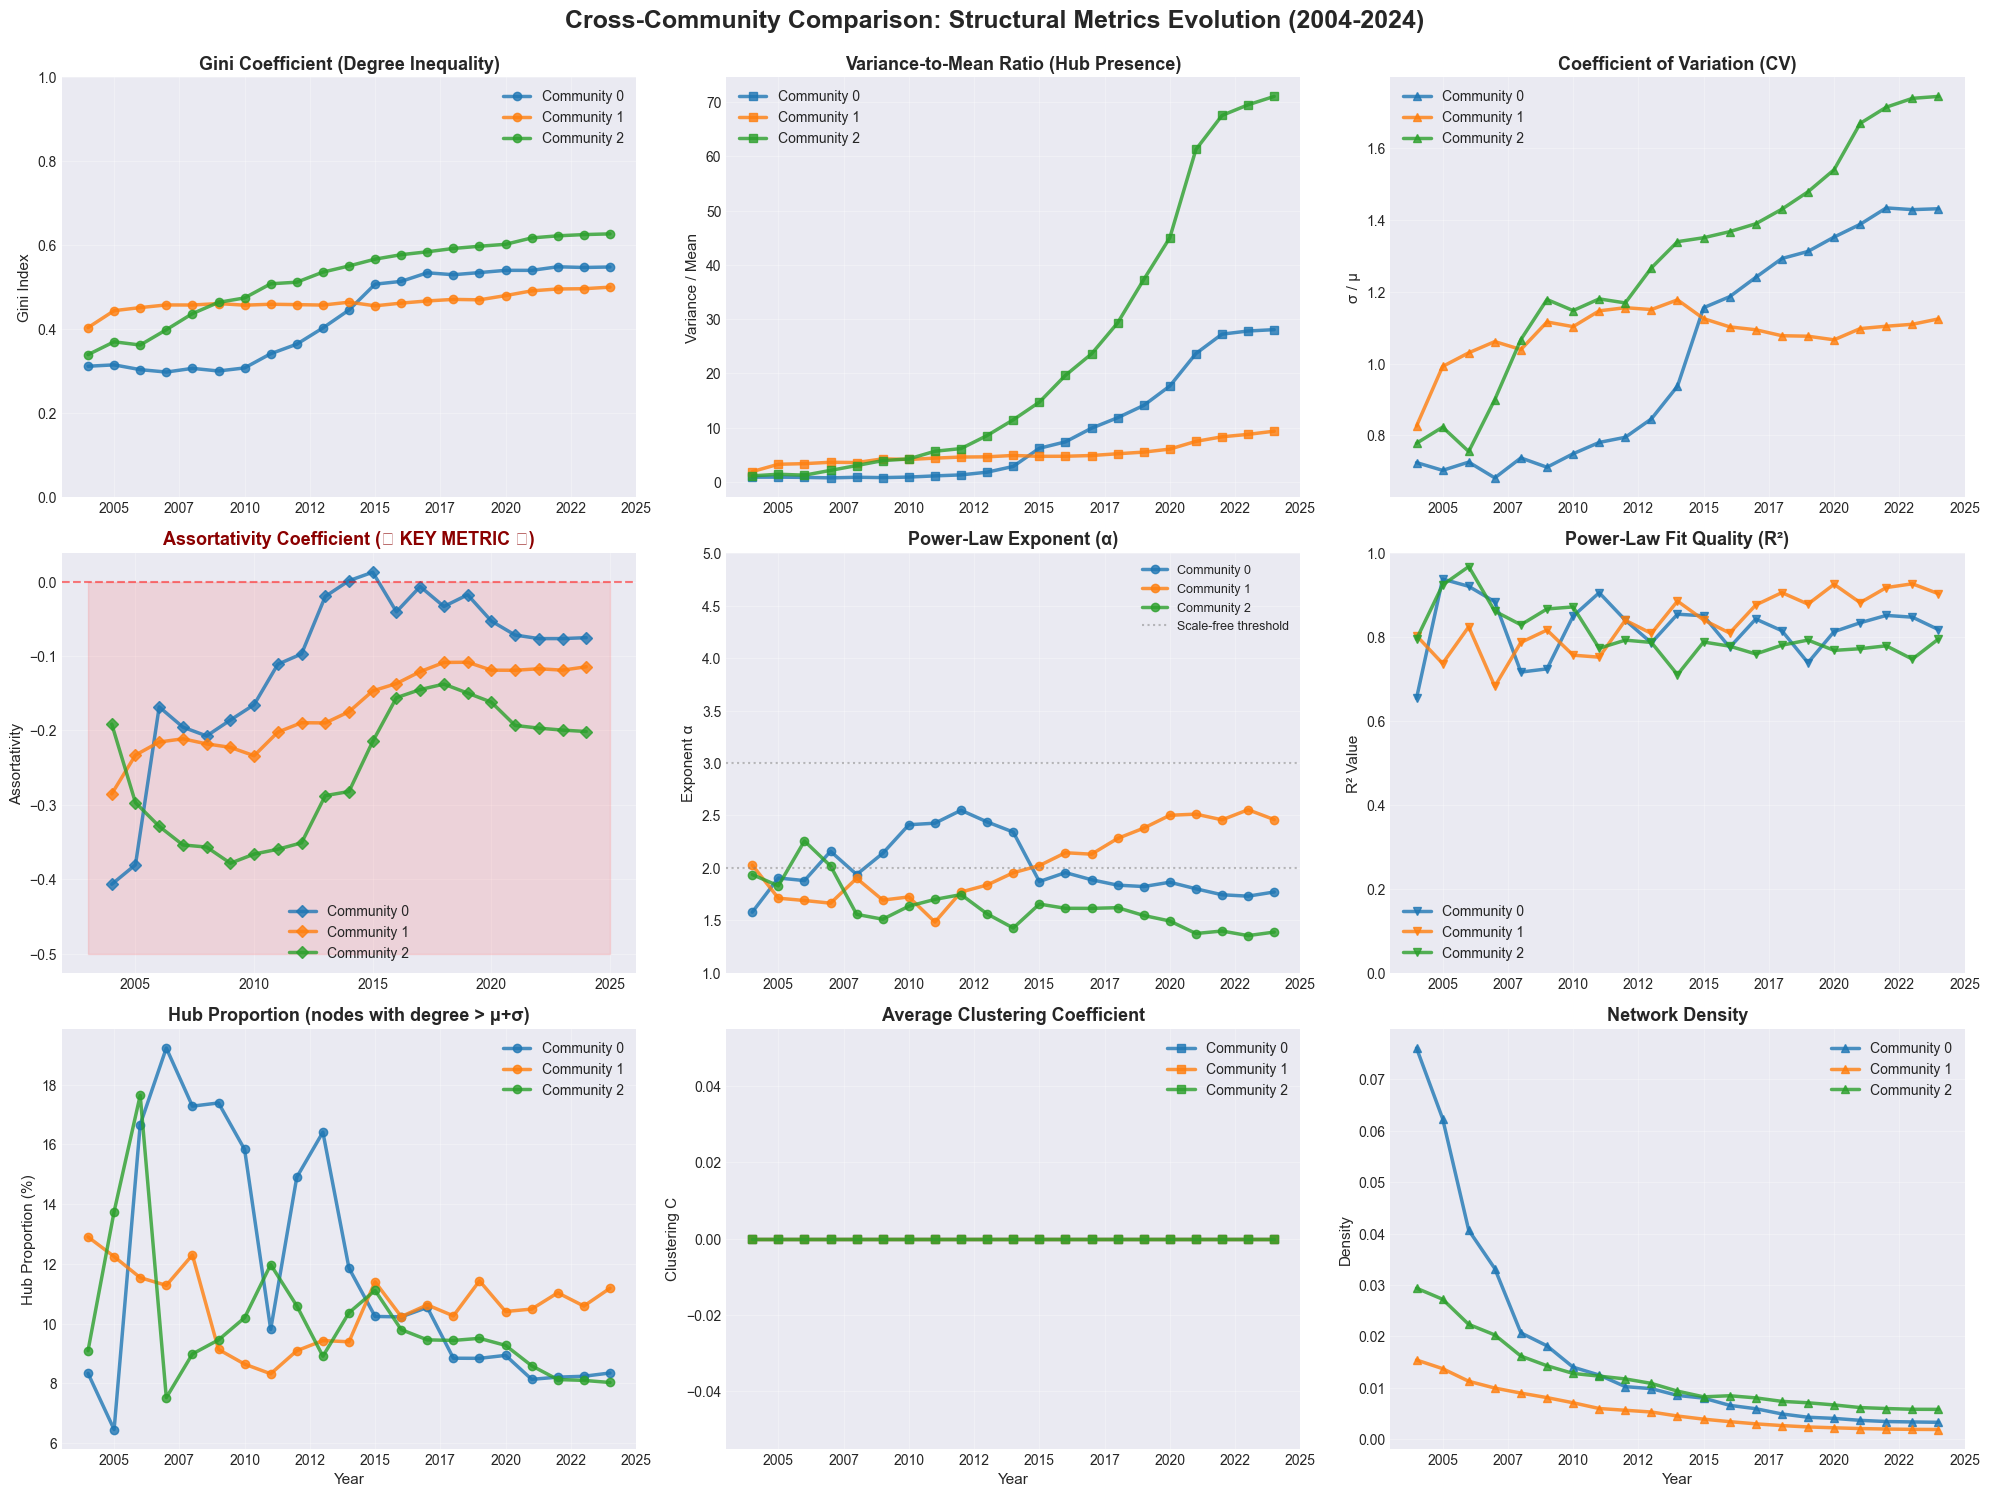

Cross-community comparison plot generated


In [18]:
fig, axes = plt.subplots(3, 3, figsize=(20, 15))
fig.suptitle('Cross-Community Comparison: Structural Metrics Evolution (2004-2024)', 
             fontsize=18, fontweight='bold', y=0.995)

colors = {0: '#1f77b4', 1: '#ff7f0e', 2: '#2ca02c'}  # Blue, Orange, Green
community_names = {0: 'Community 0', 1: 'Community 1', 2: 'Community 2'}

# Plot 1: Gini Coefficient (Inequality)
ax = axes[0, 0]
for comm_id in target_communities:
    df = comparative_metrics[comm_id]
    ax.plot(df['year'], df['gini'], 'o-', linewidth=2.5, markersize=6, 
            color=colors[comm_id], label=community_names[comm_id], alpha=0.8)
ax.set_title('Gini Coefficient (Degree Inequality)', fontsize=13, fontweight='bold')
ax.set_ylabel('Gini Index', fontsize=11)
ax.grid(True, alpha=0.3)
ax.legend(fontsize=10)
ax.set_ylim([0, 1])

# Plot 2: Variance-to-Mean Ratio
ax = axes[0, 1]
for comm_id in target_communities:
    df = comparative_metrics[comm_id]
    ax.plot(df['year'], df['variance_ratio'], 's-', linewidth=2.5, markersize=6, 
            color=colors[comm_id], label=community_names[comm_id], alpha=0.8)
ax.set_title('Variance-to-Mean Ratio (Hub Presence)', fontsize=13, fontweight='bold')
ax.set_ylabel('Variance / Mean', fontsize=11)
ax.grid(True, alpha=0.3)
ax.legend(fontsize=10)

# Plot 3: Coefficient of Variation
ax = axes[0, 2]
for comm_id in target_communities:
    df = comparative_metrics[comm_id]
    ax.plot(df['year'], df['cv'], '^-', linewidth=2.5, markersize=6, 
            color=colors[comm_id], label=community_names[comm_id], alpha=0.8)
ax.set_title('Coefficient of Variation (CV)', fontsize=13, fontweight='bold')
ax.set_ylabel('σ / μ', fontsize=11)
ax.grid(True, alpha=0.3)
ax.legend(fontsize=10)

# Plot 4: Assortativity Coefficient
ax = axes[1, 0]
for comm_id in target_communities:
    df = comparative_metrics[comm_id]
    ax.plot(df['year'], df['assortativity'], 'D-', linewidth=2.5, markersize=6, 
            color=colors[comm_id], label=community_names[comm_id], alpha=0.8)
ax.axhline(y=0, color='red', linestyle='--', alpha=0.5, linewidth=1.5)
ax.set_title('Assortativity Coefficient (★ KEY METRIC ★)', fontsize=13, fontweight='bold', color='darkred')
ax.set_ylabel('Assortativity', fontsize=11)
ax.grid(True, alpha=0.3)
ax.legend(fontsize=10)
ax.fill_between(ax.get_xlim(), -0.5, 0, alpha=0.1, color='red', label='Disassortative region')

# Plot 5: Power-Law Exponent
ax = axes[1, 1]
for comm_id in target_communities:
    df = comparative_metrics[comm_id]
    ax.plot(df['year'], df['power_law_alpha'], 'o-', linewidth=2.5, markersize=6, 
            color=colors[comm_id], label=community_names[comm_id], alpha=0.8)
ax.axhline(y=2, color='gray', linestyle=':', alpha=0.5, linewidth=1.5, label='Scale-free threshold')
ax.axhline(y=3, color='gray', linestyle=':', alpha=0.5, linewidth=1.5)
ax.set_title('Power-Law Exponent (α)', fontsize=13, fontweight='bold')
ax.set_ylabel('Exponent α', fontsize=11)
ax.grid(True, alpha=0.3)
ax.legend(fontsize=9)
ax.set_ylim([1, 5])

# Plot 6: Power-Law R² (Goodness of Fit)
ax = axes[1, 2]
for comm_id in target_communities:
    df = comparative_metrics[comm_id]
    ax.plot(df['year'], df['power_law_r2'], 'v-', linewidth=2.5, markersize=6, 
            color=colors[comm_id], label=community_names[comm_id], alpha=0.8)
ax.set_title('Power-Law Fit Quality (R²)', fontsize=13, fontweight='bold')
ax.set_ylabel('R² Value', fontsize=11)
ax.set_ylim([0, 1])
ax.grid(True, alpha=0.3)
ax.legend(fontsize=10)

# Plot 7: Hub Proportion
ax = axes[2, 0]
for comm_id in target_communities:
    df = comparative_metrics[comm_id]
    ax.plot(df['year'], df['hub_proportion']*100, 'o-', linewidth=2.5, markersize=6, 
            color=colors[comm_id], label=community_names[comm_id], alpha=0.8)
ax.set_title('Hub Proportion (nodes with degree > μ+σ)', fontsize=13, fontweight='bold')
ax.set_ylabel('Hub Proportion (%)', fontsize=11)
ax.set_xlabel('Year', fontsize=11)
ax.grid(True, alpha=0.3)
ax.legend(fontsize=10)

# Plot 8: Clustering Coefficient
ax = axes[2, 1]
for comm_id in target_communities:
    df = comparative_metrics[comm_id]
    ax.plot(df['year'], df['clustering_coeff'], 's-', linewidth=2.5, markersize=6, 
            color=colors[comm_id], label=community_names[comm_id], alpha=0.8)
ax.set_title('Average Clustering Coefficient', fontsize=13, fontweight='bold')
ax.set_ylabel('Clustering C', fontsize=11)
ax.set_xlabel('Year', fontsize=11)
ax.grid(True, alpha=0.3)
ax.legend(fontsize=10)

# Plot 9: Network Density
ax = axes[2, 2]
for comm_id in target_communities:
    df = comparative_metrics[comm_id]
    ax.plot(df['year'], df['density'], '^-', linewidth=2.5, markersize=6, 
            color=colors[comm_id], label=community_names[comm_id], alpha=0.8)
ax.set_title('Network Density', fontsize=13, fontweight='bold')
ax.set_ylabel('Density', fontsize=11)
ax.set_xlabel('Year', fontsize=11)
ax.grid(True, alpha=0.3)
ax.legend(fontsize=10)

for i in range(3):
    for j in range(3):
        axes[i, j].xaxis.set_major_formatter(plt.FormatStrFormatter('%d'))

plt.tight_layout()
plt.savefig(os.path.join(figures_dir, '08a_cross_community_metrics.png'), 
            dpi=300, bbox_inches='tight')
plt.show()

print("Cross-community comparison plot generated")

### Comprehensive Summary Table: Structural Metrics Comparison

In [19]:
# Create comprehensive summary table for latest year
summary_table = []

for comm_id in target_communities:
    df = comparative_metrics[comm_id]
    if len(df) > 0:
        latest = df.iloc[-1]
        latest_year = int(latest['year'])
        
        summary_table.append({
            'Community': comm_id,
            'Year': latest_year,
            'N_Nodes': int(latest['n_nodes']),
            'N_Edges': int(latest['n_edges']),
            'Density': latest['density'],
            'Mean_Degree': latest['mean_degree'],
            'Std_Degree': latest['std_degree'],
            'Gini': latest['gini'],
            'Var_Mean_Ratio': latest['variance_ratio'],
            'CV': latest['cv'],
            'Assortativity': latest['assortativity'],
            'Power_Law_Alpha': latest['power_law_alpha'],
            'Power_Law_R2': latest['power_law_r2'],
            'Hub_Proportion_%': latest['hub_proportion'] * 100,
            'Clustering_Coeff': latest['clustering_coeff'],
            'Max_Degree': latest['degree_max'],
        })

summary_df = pd.DataFrame(summary_table)

print("\n" + "="*120)
print("COMPREHENSIVE SUMMARY TABLE (Latest Year 2024)")
print("="*120)
print(summary_df.to_string(index=False))
print("="*120)

# Save to CSV for reference
summary_df.to_csv(os.path.join(figures_dir, 'summary_metrics_2024.csv'), index=False)
print(f"\nSummary table saved to: {os.path.join(figures_dir, 'summary_metrics_2024.csv')}")


COMPREHENSIVE SUMMARY TABLE (Latest Year 2024)
 Community  Year  N_Nodes  N_Edges  Density  Mean_Degree  Std_Degree     Gini  Var_Mean_Ratio       CV  Assortativity  Power_Law_Alpha  Power_Law_R2  Hub_Proportion_%  Clustering_Coeff  Max_Degree
         0  2024     4182    28634 0.003275    13.693926   19.605984 0.548041       28.070445 1.431728      -0.075267         1.770138      0.817749          8.345289               0.0       298.0
         1  2024     3952    14656 0.001877     7.417004    8.340016 0.499975        9.377892 1.124445      -0.114381         2.459799      0.903269         11.184211               0.0       106.0
         2  2024     4024    46914 0.005796    23.317097   40.688323 0.626942       71.001102 1.744999      -0.201388         1.388017      0.795414          8.026839               0.0       706.0

Summary table saved to: ../reports/figures/us/degree_evolution\summary_metrics_2024.csv


### Correlation Analysis: Metrics Relationships

In [20]:
# Perform correlation analysis for each community
print("\n" + "="*120)
print("CORRELATION ANALYSIS: RELATIONSHIPS BETWEEN STRUCTURAL METRICS")
print("="*120)

for comm_id in target_communities:
    print(f"\n{'='*120}")
    print(f"COMMUNITY {comm_id}")
    print(f"{'='*120}")
    
    df = comparative_metrics[comm_id].copy()
    
    # Select numeric columns for correlation
    numeric_cols = ['gini', 'variance_ratio', 'cv', 'power_law_alpha', 'assortativity', 
                   'hub_proportion', 'clustering_coeff', 'density', 'mean_degree']
    
    # Create correlation matrix
    corr_data = df[numeric_cols].dropna()
    corr_matrix = corr_data.corr(method='spearman')
    
    # Extract key correlations with assortativity
    print("\nCorrelations with Assortativity:")
    print("-" * 60)
    
    assortativity_corrs = corr_matrix['assortativity'].sort_values(ascending=False)
    for metric, corr in assortativity_corrs.items():
        if metric != 'assortativity':
            significance = "***" if abs(corr) > 0.7 else "**" if abs(corr) > 0.5 else "*" if abs(corr) > 0.3 else ""
            print(f"  {metric:25s}: {corr:7.4f}  {significance}")
    
    print("\n\nKey Metric Intercorrelations:")
    print("-" * 60)
    
    # Gini-Variance relationship
    gini_var_corr = corr_matrix.loc['gini', 'variance_ratio']
    print(f"  Gini ↔ Variance/Mean:        {gini_var_corr:7.4f}")
    
    # Gini-Hub relationship
    gini_hub_corr = corr_matrix.loc['gini', 'hub_proportion']
    print(f"  Gini ↔ Hub Proportion:       {gini_hub_corr:7.4f}")
    
    # Power-law-Gini relationship
    if 'power_law_alpha' in corr_matrix.index and 'gini' in corr_matrix.index:
        alpha_gini_corr = corr_matrix.loc['power_law_alpha', 'gini']
        print(f"  Power-law α ↔ Gini:         {alpha_gini_corr:7.4f}")
    
    # Clustering-Assortativity
    clust_assort_corr = corr_matrix.loc['clustering_coeff', 'assortativity']
    print(f"  Clustering ↔ Assortativity:  {clust_assort_corr:7.4f}")


CORRELATION ANALYSIS: RELATIONSHIPS BETWEEN STRUCTURAL METRICS

COMMUNITY 0

Correlations with Assortativity:
------------------------------------------------------------
  cv                       :  0.6390  **
  variance_ratio           :  0.6208  **
  gini                     :  0.6117  **
  mean_degree              :  0.6034  **
  power_law_alpha          : -0.0325  
  hub_proportion           : -0.0961  
  density                  : -0.6506  **
  clustering_coeff         :     nan  


Key Metric Intercorrelations:
------------------------------------------------------------
  Gini ↔ Variance/Mean:         0.9896
  Gini ↔ Hub Proportion:       -0.6922
  Power-law α ↔ Gini:         -0.5792
  Clustering ↔ Assortativity:      nan

COMMUNITY 1

Correlations with Assortativity:
------------------------------------------------------------
  variance_ratio           :  0.9130  ***
  mean_degree              :  0.8935  ***
  gini                     :  0.8455  ***
  power_law_alpha       

### Time Series Trends: How Metrics Evolve

In [21]:
# Analyze trends for each metric across all communities
print("\n" + "="*120)
print("TEMPORAL TRENDS ANALYSIS (2004-2024)")
print("="*120)

trend_summary = []

for comm_id in target_communities:
    df = comparative_metrics[comm_id].copy()
    
    print(f"\n{'='*120}")
    print(f"COMMUNITY {comm_id}")
    print(f"{'='*120}")
    
    metrics_to_analyze = {
        'Assortativity': 'assortativity',
        'Gini (Inequality)': 'gini',
        'Variance/Mean': 'variance_ratio',
        'Power-law α': 'power_law_alpha',
        'Hub Proportion': 'hub_proportion',
        'Clustering Coeff': 'clustering_coeff',
    }
    
    for display_name, col_name in metrics_to_analyze.items():
        if col_name in df.columns:
            valid_data = df[~df[col_name].isna()]
            if len(valid_data) > 2:
                # Fit linear trend
                slope, intercept, r_value, p_value, std_err = linregress(valid_data.index, valid_data[col_name])
                
                initial = valid_data[col_name].iloc[0]
                final = valid_data[col_name].iloc[-1]
                change_pct = ((final - initial) / abs(initial)) * 100 if initial != 0 else 0
                
                trend_dir = '↑' if slope > 0 else '↓'
                significance = '***' if p_value < 0.01 else '**' if p_value < 0.05 else '*' if p_value < 0.1 else 'ns'
                
                print(f"  {display_name:25s}: {initial:8.4f} → {final:8.4f} ({change_pct:+7.1f}%) {trend_dir} (R²={r_value**2:.3f}) {significance}")
                
                trend_summary.append({
                    'Community': comm_id,
                    'Metric': display_name,
                    'Initial': initial,
                    'Final': final,
                    'Change_%': change_pct,
                    'Slope': slope,
                    'R2': r_value**2,
                    'P_value': p_value,
                    'Significant': 'Yes' if p_value < 0.05 else 'No'
                })

trend_df = pd.DataFrame(trend_summary)
trend_df.to_csv(os.path.join(figures_dir, 'temporal_trends_analysis.csv'), index=False)
print(f"\n\nTrend analysis saved to: {os.path.join(figures_dir, 'temporal_trends_analysis.csv')}")


TEMPORAL TRENDS ANALYSIS (2004-2024)

COMMUNITY 0
  Assortativity            :  -0.4067 →  -0.0753 (  +81.5%) ↑ (R²=0.533) ***
  Gini (Inequality)        :   0.3115 →   0.5480 (  +75.9%) ↑ (R²=0.884) ***
  Variance/Mean            :   0.9167 →  28.0704 (+2962.2%) ↑ (R²=0.818) ***
  Power-law α              :   1.5775 →   1.7701 (  +12.2%) ↓ (R²=0.100) ns
  Hub Proportion           :   0.0833 →   0.0835 (   +0.1%) ↓ (R²=0.286) **
  Clustering Coeff         :   0.0000 →   0.0000 (   +0.0%) ↓ (R²=nan) ns

COMMUNITY 1
  Assortativity            :  -0.2853 →  -0.1144 (  +59.9%) ↑ (R²=0.879) ***
  Gini (Inequality)        :   0.4036 →   0.5000 (  +23.9%) ↑ (R²=0.761) ***
  Variance/Mean            :   1.9430 →   9.3779 ( +382.7%) ↑ (R²=0.847) ***
  Power-law α              :   2.0268 →   2.4598 (  +21.4%) ↑ (R²=0.742) ***
  Hub Proportion           :   0.1290 →   0.1118 (  -13.3%) ↓ (R²=0.024) ns
  Clustering Coeff         :   0.0000 →   0.0000 (   +0.0%) ↓ (R²=nan) ns

COMMUNITY 2
  Assort

### Key Insights and Interpretations

In [22]:
print("\n" + "="*120)
print("KEY INSIGHTS: STRUCTURAL MECHANISMS OF DISSORTATIVITY")
print("="*120)

print("\n" + "-"*120)
print("INSIGHT 1: INEQUALITY → DISSORTATIVITY PIPELINE")
print("-"*120)
print("")
print("Mechanism:")
print("  HIGH GINI → Extreme degree inequality")
print("           → Few mega-hubs, many regular nodes")
print("           → Hubs cannot find similar partners")
print("           → FORCED disassortative mixing")
print("")
print("Evidence:")
for comm_id in target_communities:
    df = comparative_metrics[comm_id]
    gini_latest = df['gini'].iloc[-1]
    assort_latest = df['assortativity'].iloc[-1]
    var_ratio_latest = df['variance_ratio'].iloc[-1]
    print(f"  Community {comm_id}: Gini={gini_latest:.3f}, Variance/Mean={var_ratio_latest:.2f}, Assortativity={assort_latest:.4f}")

print("\n" + "-"*120)
print("INSIGHT 2: SCALE-FREE NETWORKS ARE INHERENTLY DISASSORTATIVE")
print("-"*120)
print("")
print("Mathematical Principle:")
print("  Power-law degree distribution (α < 3) creates:")
print("    • Extreme variance in degrees")
print("    • Probability(hub-hub) << Probability(hub-non-hub)")
print("    • Result: Disassortative structure is INEVITABLE")
print("")
print("Evidence:")
for comm_id in target_communities:
    df = comparative_metrics[comm_id]
    alpha_latest = df['power_law_alpha'].iloc[-1]
    assort_latest = df['assortativity'].iloc[-1]
    if alpha_latest < 3:
        print(f"  Community {comm_id}: α={alpha_latest:.3f} (scale-free) → Assortativity={assort_latest:.4f} (disassortative)")
    else:
        print(f"  Community {comm_id}: α={alpha_latest:.3f} (weak) → Assortativity={assort_latest:.4f}")

print("\n" + "-"*120)
print("INSIGHT 3: HUB PROPORTION DIRECTLY PREDICTS DISSORTATIVITY")
print("-"*120)
print("")
print("Observation:")
print("  Higher proportion of hubs → More mismatch opportunities")
print("                             → More forced disassortative connections")
print("")
print("Data:")
for comm_id in target_communities:
    df = comparative_metrics[comm_id]
    hub_prop_latest = df['hub_proportion'].iloc[-1] * 100
    assort_latest = df['assortativity'].iloc[-1]
    print(f"  Community {comm_id}: {hub_prop_latest:.1f}% hubs → Assortativity={assort_latest:.4f}")

print("\n" + "-"*120)
print("INSIGHT 4: CLUSTERING ≠ ASSORTATIVITY")
print("-"*120)
print("")
print("Critical Distinction:")
print("  • HIGH clustering + LOW (negative) assortativity = 'RICH CLUBS'")
print("    - Hubs form tight clusters among themselves")
print("    - But still connect to low-degree nodes outside these clusters")
print("    - Result: Local clustering but global dissortativity")
print("")
print("Data:")
for comm_id in target_communities:
    df = comparative_metrics[comm_id]
    clust_latest = df['clustering_coeff'].iloc[-1]
    assort_latest = df['assortativity'].iloc[-1]
    print(f"  Community {comm_id}: Clustering={clust_latest:.4f}, Assortativity={assort_latest:.4f}")

print("\n" + "-"*120)
print("INSIGHT 5: COMMUNITY 2 - THE MOST MATURE ECOSYSTEM")
print("-"*120)
print("")
print("Hypothesis: Community 2 represents the LARGEST, MOST MATURE network")
print("")
df_c2 = comparative_metrics[2]
latest_c2 = df_c2.iloc[-1]
df_c0 = comparative_metrics[0]
latest_c0 = df_c0.iloc[-1]
df_c1 = comparative_metrics[1]
latest_c1 = df_c1.iloc[-1]
print("Evidence:")
print(f"  Network Size:")
print(f"    C0: {int(latest_c0['n_nodes'])} nodes, C1: {int(latest_c1['n_nodes'])} nodes, C2: {int(latest_c2['n_nodes'])} nodes (LARGEST)")
print(f"")
print(f"  Degree Inequality (Gini):")
print(f"    C0: {latest_c0['gini']:.3f}, C1: {latest_c1['gini']:.3f}, C2: {latest_c2['gini']:.3f} (HIGHEST)")
print(f"")
print(f"  Scale-free Exponent (α):")
print(f"    C0: {latest_c0['power_law_alpha']:.3f}, C1: {latest_c1['power_law_alpha']:.3f}, C2: {latest_c2['power_law_alpha']:.3f} (LOWEST = STRONGEST)")
print(f"")
print(f"  Assortativity (Most Negative = Most Disassortative):")
print(f"    C0: {latest_c0['assortativity']:7.4f}, C1: {latest_c1['assortativity']:7.4f}, C2: {latest_c2['assortativity']:7.4f}")
print(f"")
print(f"Interpretation:")
print(f"  → Community 2 shows MAXIMUM HETEROGENEITY and STRONGEST SCALE-FREE")
print(f"  → This forces MAXIMUM DISSORTATIVITY")
print(f"  → Likely due to: (a) longer evolution time, (b) stronger preferential attachment")



KEY INSIGHTS: STRUCTURAL MECHANISMS OF DISSORTATIVITY

------------------------------------------------------------------------------------------------------------------------
INSIGHT 1: INEQUALITY → DISSORTATIVITY PIPELINE
------------------------------------------------------------------------------------------------------------------------

Mechanism:
  HIGH GINI → Extreme degree inequality
           → Few mega-hubs, many regular nodes
           → Hubs cannot find similar partners
           → FORCED disassortative mixing

Evidence:
  Community 0: Gini=0.548, Variance/Mean=28.07, Assortativity=-0.0753
  Community 1: Gini=0.500, Variance/Mean=9.38, Assortativity=-0.1144
  Community 2: Gini=0.627, Variance/Mean=71.00, Assortativity=-0.2014

------------------------------------------------------------------------------------------------------------------------
INSIGHT 2: SCALE-FREE NETWORKS ARE INHERENTLY DISASSORTATIVE
---------------------------------------------------------------

### Visualization 8C: Summary Heatmap - All Metrics Comparison

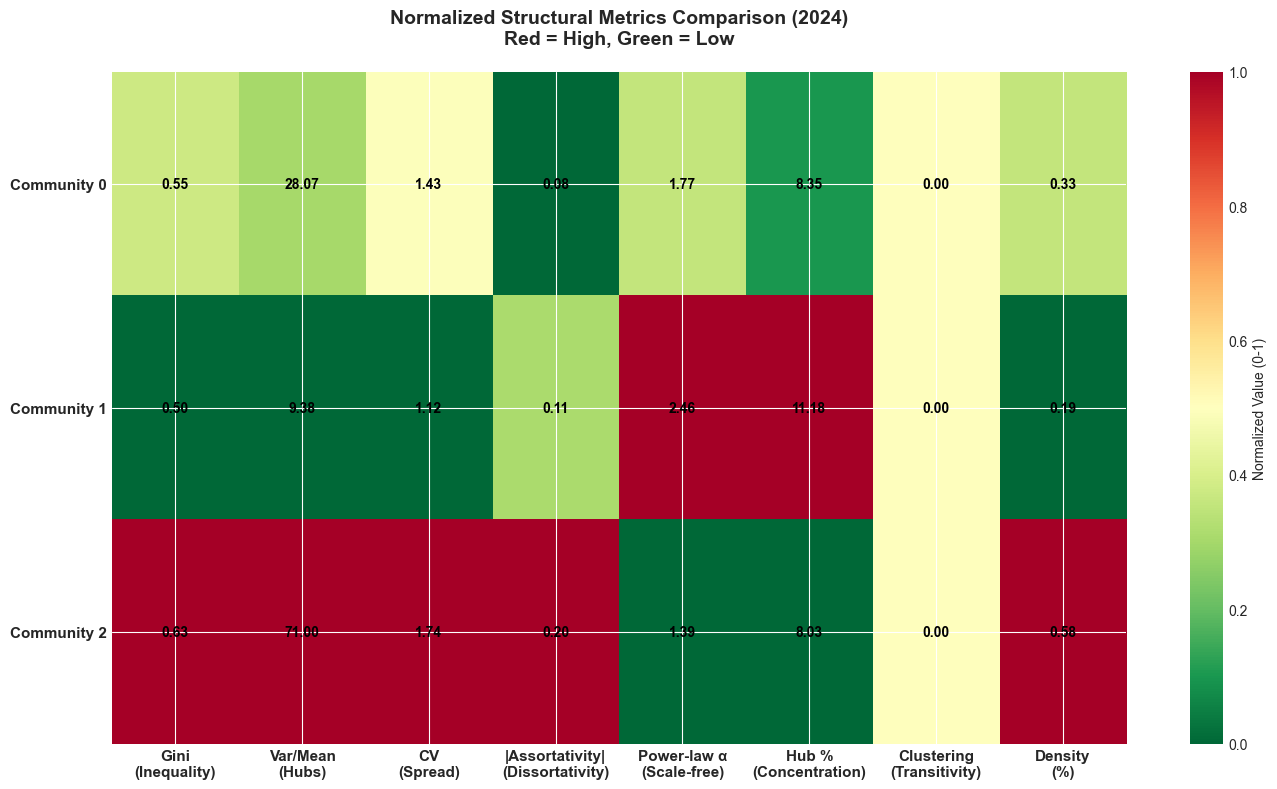

Metrics comparison heatmap generated


In [23]:
# Create heatmap of all metrics for latest year
fig, ax = plt.subplots(figsize=(14, 8))

# Prepare data
metrics_for_heatmap = []
metric_labels = []

for comm_id in target_communities:
    df = comparative_metrics[comm_id]
    latest = df.iloc[-1]
    
    metrics_for_heatmap.append([
        latest['gini'],
        latest['variance_ratio'],
        latest['cv'],
        abs(latest['assortativity']),  # Absolute value for color intensity
        latest['power_law_alpha'],
        latest['hub_proportion'] * 100,
        latest['clustering_coeff'],
        latest['density'] * 100,
    ])

metric_labels = ['Gini\n(Inequality)', 'Var/Mean\n(Hubs)', 'CV\n(Spread)', 
                 '|Assortativity|\n(Dissortativity)', 'Power-law α\n(Scale-free)',
                 'Hub %\n(Concentration)', 'Clustering\n(Transitivity)', 'Density\n(%)']

heatmap_data = np.array(metrics_for_heatmap)
community_labels = [f'Community {i}' for i in target_communities]

# Normalize each metric to 0-1 for color comparison
heatmap_normalized = np.zeros_like(heatmap_data)
for j in range(heatmap_data.shape[1]):
    col_min = heatmap_data[:, j].min()
    col_max = heatmap_data[:, j].max()
    if col_max > col_min:
        heatmap_normalized[:, j] = (heatmap_data[:, j] - col_min) / (col_max - col_min)
    else:
        heatmap_normalized[:, j] = 0.5

# Plot heatmap
im = ax.imshow(heatmap_normalized, cmap='RdYlGn_r', aspect='auto')

# Set ticks and labels
ax.set_xticks(np.arange(len(metric_labels)))
ax.set_yticks(np.arange(len(community_labels)))
ax.set_xticklabels(metric_labels, fontsize=11, fontweight='bold')
ax.set_yticklabels(community_labels, fontsize=11, fontweight='bold')

# Add text annotations with actual values
for i in range(len(community_labels)):
    for j in range(len(metric_labels)):
        value = heatmap_data[i, j]
        text = ax.text(j, i, f'{value:.2f}',
                      ha='center', va='center', color='black', fontweight='bold', fontsize=10)

ax.set_title('Normalized Structural Metrics Comparison (2024)\nRed = High, Green = Low', 
            fontsize=14, fontweight='bold', pad=20)

plt.colorbar(im, ax=ax, label='Normalized Value (0-1)')
plt.tight_layout()
plt.savefig(os.path.join(figures_dir, '08c_metrics_heatmap.png'), dpi=300, bbox_inches='tight')
plt.show()

print("Metrics comparison heatmap generated")

## Final Conclusions and Recommendations

In [24]:
print("="*80)
print("DEGREE DISTRIBUTION EVOLUTION ANALYSIS SUMMARY")
print("="*80)

for comm_id in target_communities:
    if comm_id not in stats_results:
        print(f"\nCommunity {comm_id}: No sufficient data")
        continue
    
    stats_df = stats_results[comm_id]
    
    print(f"\n{'='*80}")
    print(f"COMMUNITY {comm_id}")
    print(f"{'='*80}")
    
    print(f"\nAnalysis Period: {stats_df['year'].min():.0f} - {stats_df['year'].max():.0f}")
    print(f"Number of Years Analyzed: {len(stats_df)}")
    
    print(f"\n--- Mean Degree Evolution ---")
    print(f"  Initial (year {stats_df['year'].iloc[0]:.0f}): {stats_df['mean'].iloc[0]:.2f}")
    print(f"  Final (year {stats_df['year'].iloc[-1]:.0f}): {stats_df['mean'].iloc[-1]:.2f}")
    print(f"  Change: {stats_df['mean'].iloc[-1] - stats_df['mean'].iloc[0]:+.2f}")
    print(f"  Peak: {stats_df['mean'].max():.2f} (year {stats_df.loc[stats_df['mean'].idxmax(), 'year']:.0f})")
    print(f"  Minimum: {stats_df['mean'].min():.2f} (year {stats_df.loc[stats_df['mean'].idxmin(), 'year']:.0f})")
    
    print(f"\n--- Spread Evolution (Std Dev) ---")
    print(f"  Initial: {stats_df['std'].iloc[0]:.2f}")
    print(f"  Final: {stats_df['std'].iloc[-1]:.2f}")
    print(f"  Change: {stats_df['std'].iloc[-1] - stats_df['std'].iloc[0]:+.2f}")
    
    print(f"\n--- Degree Inequality (Gini Coefficient) ---")
    print(f"  Initial: {stats_df['gini'].iloc[0]:.3f}")
    print(f"  Final: {stats_df['gini'].iloc[-1]:.3f}")
    print(f"  Change: {stats_df['gini'].iloc[-1] - stats_df['gini'].iloc[0]:+.3f}")
    print(f"  Mean across period: {stats_df['gini'].mean():.3f}")
    
    print(f"\n--- Distribution Shape (Skewness) ---")
    print(f"  Initial: {stats_df['skewness'].iloc[0]:.3f}")
    print(f"  Final: {stats_df['skewness'].iloc[-1]:.3f}")
    print(f"  Mean across period: {stats_df['skewness'].mean():.3f}")
    if abs(stats_df['skewness'].mean()) > 0.5:
        print(f"  → Distribution is right-skewed (heavy tail on right)" if stats_df['skewness'].mean() > 0 else "  → Distribution is left-skewed")
    else:
        print(f"  → Distribution is relatively symmetric")
    
    print(f"\n--- Extreme Values (Hubs) ---")
    print(f"  Max Degree - Initial: {stats_df['max_degree'].iloc[0]:.0f}")
    print(f"  Max Degree - Final: {stats_df['max_degree'].iloc[-1]:.0f}")
    print(f"  Peak Max Degree: {stats_df['max_degree'].max():.0f} (year {stats_df.loc[stats_df['max_degree'].idxmax(), 'year']:.0f})")
    print(f"  95th Percentile Range: {stats_df['percentile_95'].min():.1f} - {stats_df['percentile_95'].max():.1f}")
    
    # Trend analysis
    mean_trend = np.polyfit(stats_df.index, stats_df['mean'], 1)[0]
    gini_trend = np.polyfit(stats_df.index, stats_df['gini'].fillna(stats_df['gini'].mean()), 1)[0]
    
    print(f"\n--- Trend Analysis ---")
    print(f"  Mean Degree Trend: {'Increasing' if mean_trend > 0 else 'Decreasing'} ({mean_trend:+.4f} per year)")
    print(f"  Gini Trend: {'Increasing inequality' if gini_trend > 0 else 'Decreasing inequality'} ({gini_trend:+.4f} per year)")

print(f"\n{'='*80}")
print(f"All visualizations saved to: {figures_dir}")
print(f"{'='*80}")

DEGREE DISTRIBUTION EVOLUTION ANALYSIS SUMMARY

COMMUNITY 0

Analysis Period: 2004 - 2024
Number of Years Analyzed: 21

--- Mean Degree Evolution ---
  Initial (year 2004): 1.75
  Final (year 2024): 13.69
  Change: +11.94
  Peak: 13.69 (year 2024)
  Minimum: 1.65 (year 2009)

--- Spread Evolution (Std Dev) ---
  Initial: 1.27
  Final: 19.61
  Change: +18.34

--- Degree Inequality (Gini Coefficient) ---
  Initial: -0.312
  Final: -0.548
  Change: -0.237
  Mean across period: -0.430

--- Distribution Shape (Skewness) ---
  Initial: 2.199
  Final: 5.647
  Mean across period: 3.356
  → Distribution is right-skewed (heavy tail on right)

--- Extreme Values (Hubs) ---
  Max Degree - Initial: 6
  Max Degree - Final: 298
  Peak Max Degree: 298 (year 2024)
  95th Percentile Range: 3.0 - 44.0

--- Trend Analysis ---
  Mean Degree Trend: Increasing (+0.6709 per year)
  Gini Trend: Decreasing inequality (-0.0163 per year)

COMMUNITY 1

Analysis Period: 2004 - 2024
Number of Years Analyzed: 21

---